# An Exploration of Various Template Fitting Methods for the LSQ Variability Survey
#### Kyra Bettwy

## Imports and Loading in Data
I have not downloaded the full 25,000 LSQ stars to the GitHub, but have instead included the "template" and "sparse" subsets that I use in my analysis. Below are the preprocessed csv files. To define the template lightcurves I made cuts of n_points>100, median_err<0.033, 0.4<amplitude<1.5, and phase coverage > 70%, and period between 0.44-0.89. For sparse curves I made cuts of >120kpc and <60 points. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline

#### 'template' and 'sparse' curves

In [2]:
lc_df_good = pd.read_csv("filtered_lightcurves_ab.csv")
lc_df_bad = pd.read_csv("filtered_lightcurves_sparse_ab.csv")

#### Example lightcurves

In [3]:
def fold_phase_min_light(time, flux, period):
    raw_phase = (time / period) % 2.0
    idx_min = np.argmax(flux)
    phi0 = raw_phase[idx_min]

    shifted_phase = (raw_phase - phi0) % 2.0
    return shifted_phase

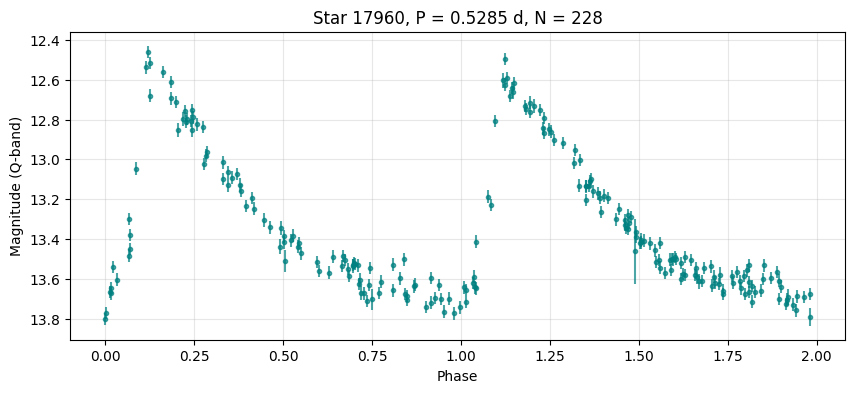

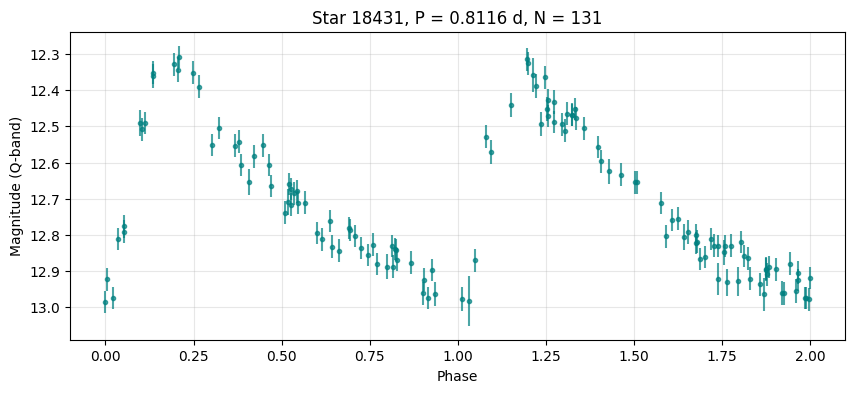

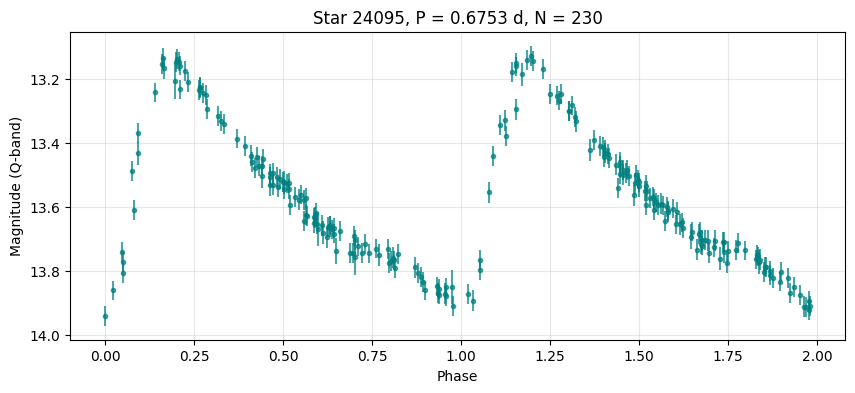

In [4]:
np.random.seed(42)
sample_ids = np.random.choice(lc_df_good["star_id"].unique(), size=3, replace=False)

for sid in sample_ids:
    g = lc_df_good[lc_df_good["star_id"] == sid]
    period = g["period"].iloc[0]

    phase = fold_phase_min_light(g["time"].values, g["mag"].values, period)

    plt.figure(figsize=(10, 4))
    plt.errorbar(phase, g["mag"], yerr=g["mag_err"], fmt=".", color="teal", alpha=0.7)

    plt.title(f"Star {sid}, P = {period:.4f} d, N = {len(g)}")
    plt.xlabel("Phase")
    plt.ylabel("Magnitude (Q-band)")
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3)
    plt.show()

# Creating subset of templates: Hierarchical clustering on template data from Gavrilchenko et al. 2014

### Selecting template stars

In [5]:
selected_ids = []

for sid, g in lc_df_good.groupby("star_id"):
    p = g["period"].iloc[0]
    t = g["time"].values
    selected_ids.append(sid)

print("Selected template-building stars:", len(selected_ids))

Selected template-building stars: 418


### Phase folding, smoothing using Savitzky-Golay window, normalizing, and using 1,000pt phase grid as clustering

In [6]:
def normalize_and_interpolate(time, mag, period, n_phase=1000):
    phase = ((time - time.min()) / period) % 1.0
    idx = np.argsort(phase)
    phase = phase[idx]
    mag   = mag[idx]

    phase_grid = np.linspace(0.0, 1.0, n_phase, endpoint=False)
    mag_interp = np.interp(phase_grid, phase, mag,
                           left=mag[0], right=mag[-1])
    mag_smooth = savgol_filter(mag_interp, 51, 3)

    mu = mag_smooth.mean()
    sigma = mag_smooth.std()
    if sigma < 1e-6:
        mag_norm = mag_smooth * 0.0
    else:
        mag_norm = (mag_smooth - mu) / sigma

    return phase_grid, mag_norm

In [7]:
phase_grid = np.linspace(0, 1, 1000, endpoint=False)
X = []   
star_list = [] 

for sid, g in lc_df_good.groupby("star_id"):
    if sid not in selected_ids:
        continue
    
    p  = g["period"].iloc[0]
    t  = g["time"].values
    m  = g["mag"].values

    _, curve = normalize_and_interpolate(t, m, p)
    X.append(curve)
    star_list.append(sid)

X = np.vstack(X)
print(X.shape)

(418, 1000)


### Computing pairwise Euclidean distances, and averaging curves into templates

Gavrilchenko uses a slightly different approach, with a larger overall subset of 1633 W1 lightcurves and 840 W2 lightcurves for initial analysis, and a final cluster number of 10 lightcurves for each W1 and W2 subset. I was less extreme when forming clusters in order to better preserve the subtle individual characteristics of the RRL curves. 

In [8]:
dist_condensed = pdist(X, metric="euclidean")

Z = linkage(dist_condensed, method="average")

num_clusters = 100
labels = fcluster(Z, t=num_clusters, criterion="maxclust")

In [9]:
templates = {}
unique = np.unique(labels)

for cid in unique:              
    members = X[labels == cid] 
    if len(members) == 0:
        continue
    template_curve = np.mean(members, axis=0)
    templates[cid] = template_curve

#### Post-processing smoothing of data, discarding overly noisy samples

In [10]:
cluster_sizes = {cid: np.sum(labels == cid) for cid in templates.keys()}

good_templates = {}
for cid, curve in templates.items():
    second_deriv = np.diff(curve, n=2)
    jaggedness = np.std(second_deriv)

    if jaggedness > 0.002:
        continue

    good_templates[cid] = curve

good_templates = {new_id: curve for new_id, (old_id, curve) in enumerate(good_templates.items())}

print("Good templates:", len(good_templates))

Good templates: 22


In [11]:
def plot_each_template_separately(templates):
    for tid, curve in templates.items():
        N = len(curve)
        idx_min = np.argmax(curve)
        curve_shifted = np.roll(curve, -idx_min)
        phase = np.linspace(0, 1, N, endpoint=False)
        plt.figure(figsize=(6, 4))
        plt.plot(phase, curve_shifted, lw=2.5, color="firebrick")
        
        plt.title(f"RR Lyrae Template {tid}", fontsize=14)
        plt.xlabel("Phase", fontsize=12)
        plt.ylabel("Normalized Magnitude", fontsize=12)
        plt.grid(alpha=0.3)

        plt.gca().invert_yaxis()
        plt.ylim(curve_shifted.max()+0.5, curve_shifted.min()-0.5)

        plt.tight_layout()
        plt.show()


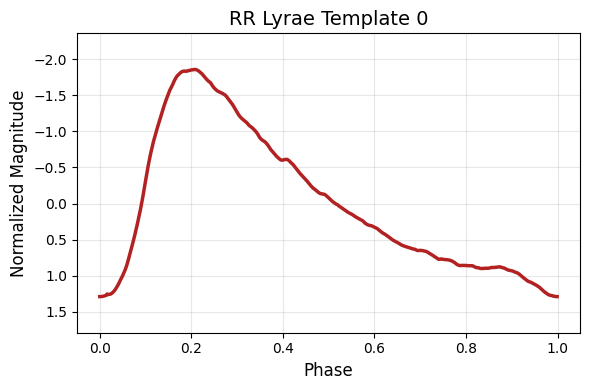

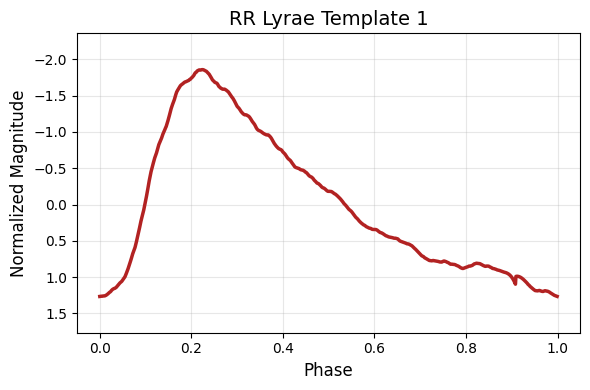

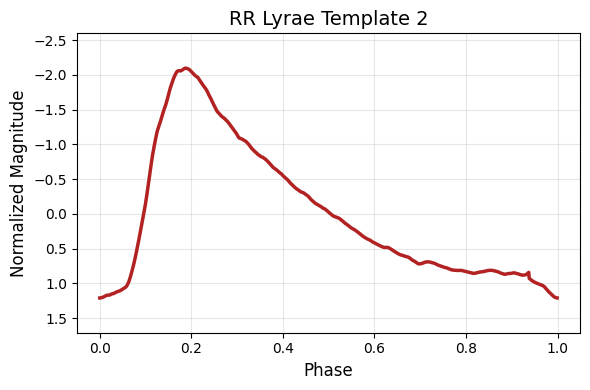

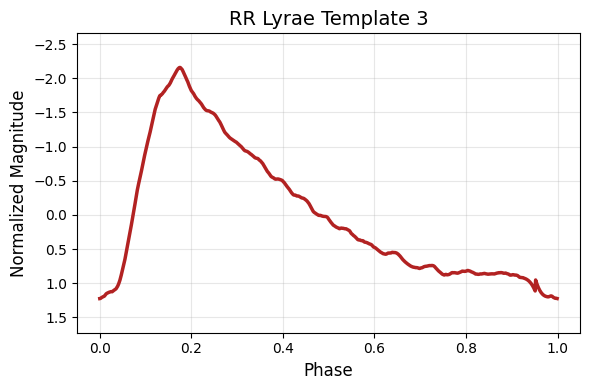

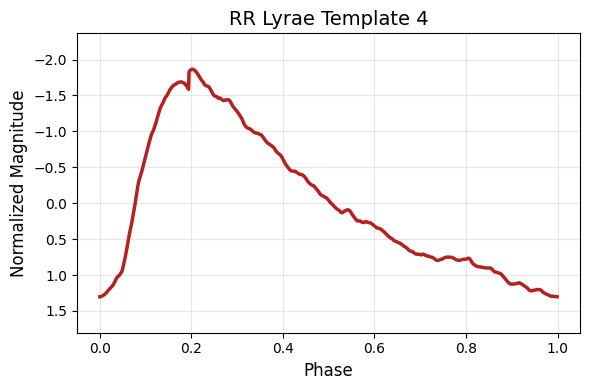

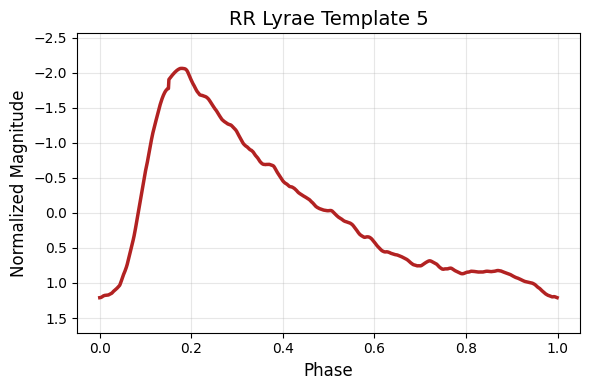

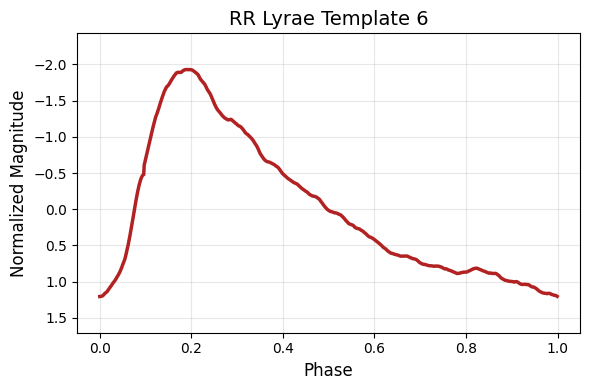

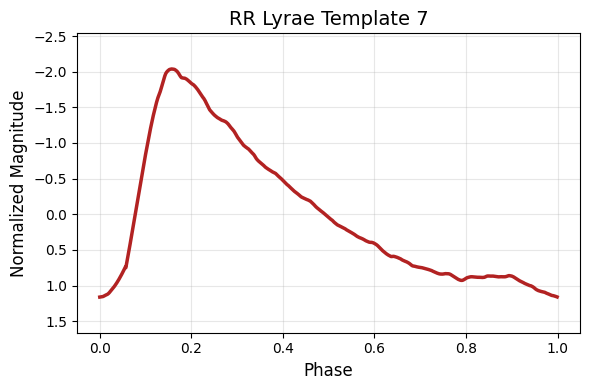

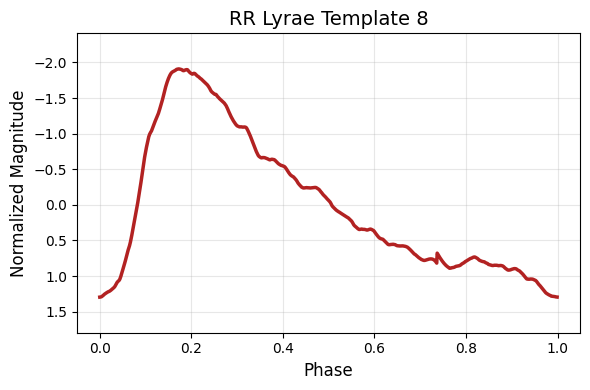

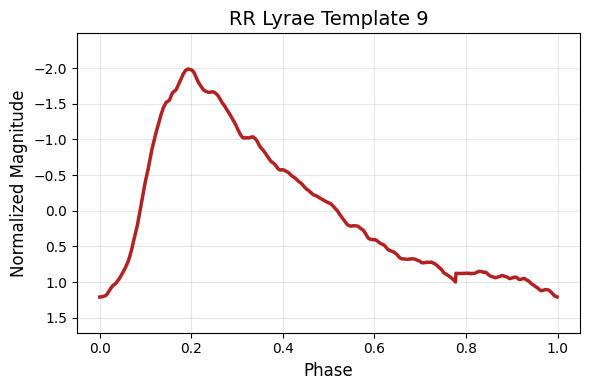

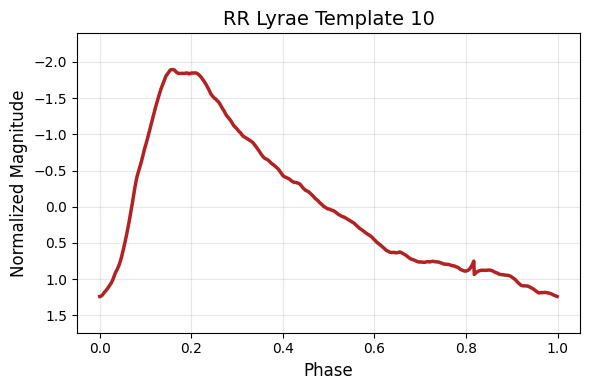

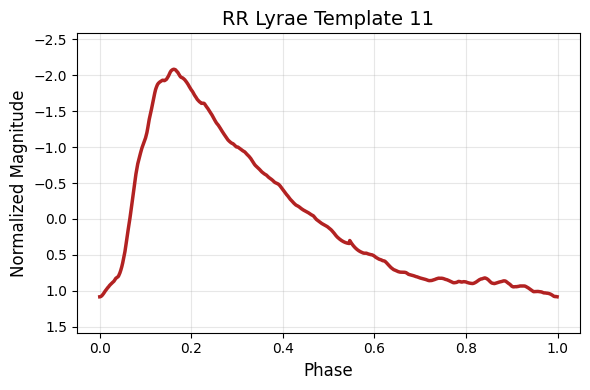

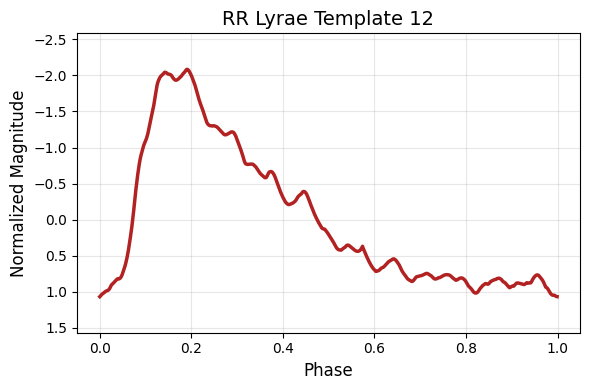

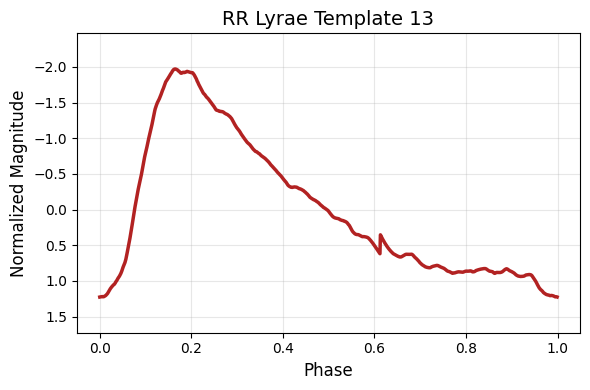

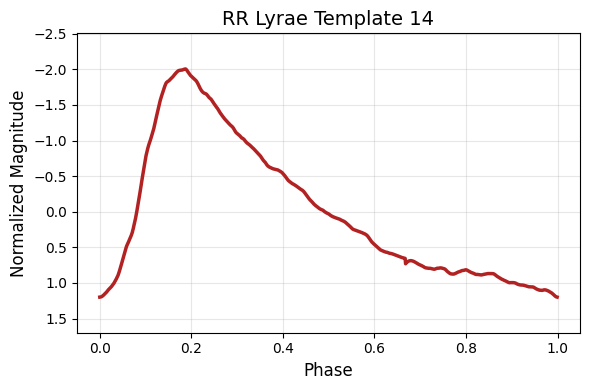

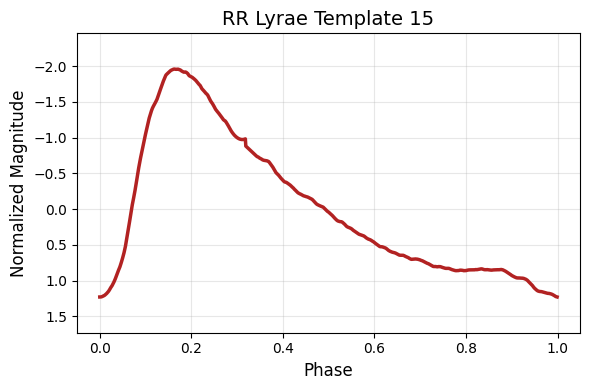

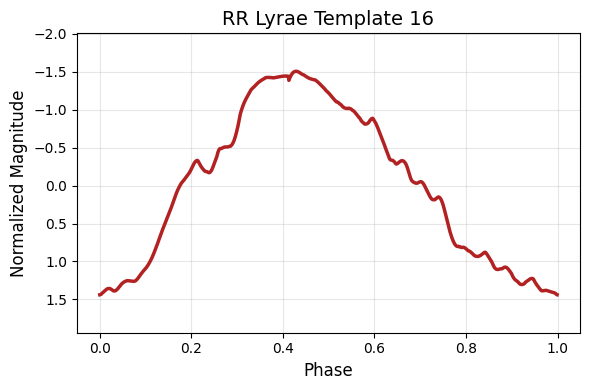

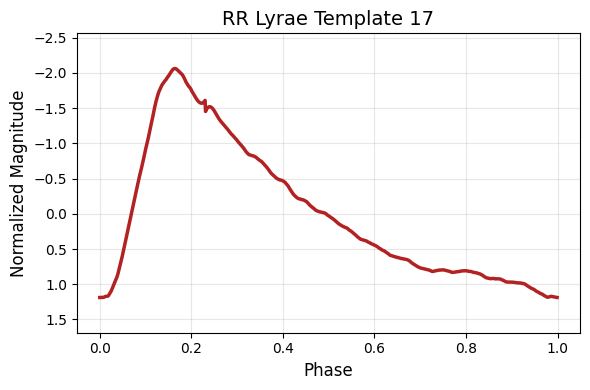

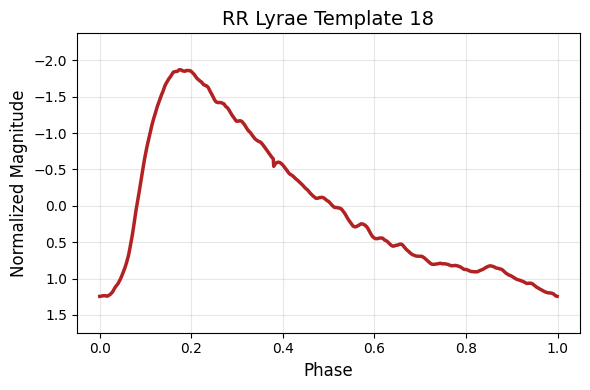

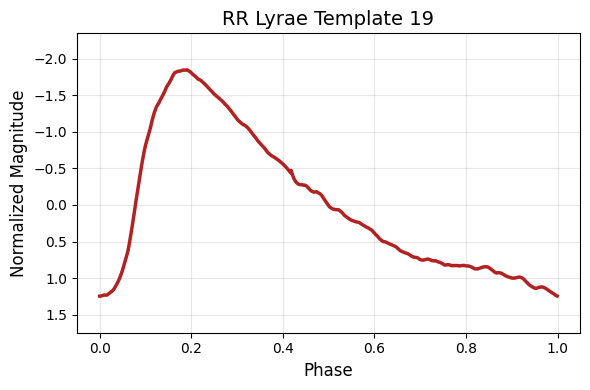

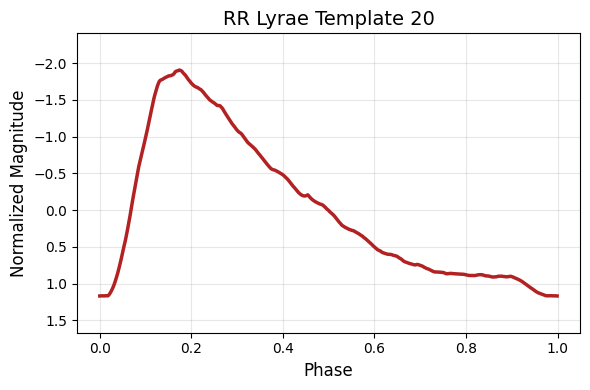

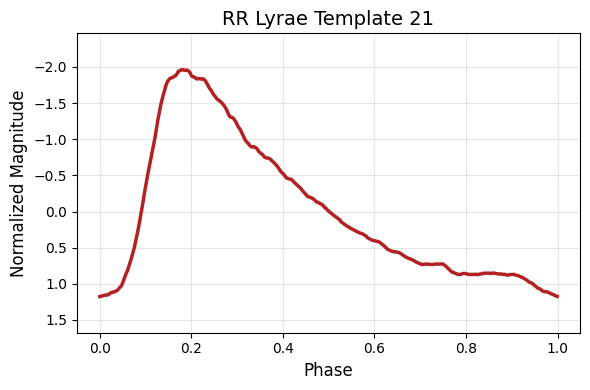

In [12]:
plot_each_template_separately(good_templates)

## Amplitude and phase shift/stretching for individual lightcurves

Here I iterate over 4 parameters, amplitude, vertical shift, phase shift, and horizontal stretch for each template, and find the best fit using a chi2 metric. Sesar et al. 2010 uses a similar approach for multiband data with a chi2 approximation using a ζ function. However, this metric was initially created to classify RRL, and my goal is not to classify RRL but to find their individualized shape among a pure RRL dataset, so I substituted this with a pure chi2 metric.

In [13]:
def fit_template_to_star(t, m, err, period, template, phase_grid=None):
    if phase_grid is None:
        L = len(template)
        phase_grid = np.linspace(0, 1, L, endpoint=False)

    phase = ((t - t.min()) / period) % 1.0
    
    phase_ext = np.concatenate([phase_grid, phase_grid + 1.0])
    template_ext = np.concatenate([template, template])
    
    cs = CubicSpline(phase_ext, template_ext) ## this is used to avoid boundary issues

    def tmpl_interp(ph, phi0, s):
        ph_wrapped = ((ph - phi0) * s) % 1.0
        return cs(ph_wrapped)

    def chi2(params):
        m0, A, phi0, s = params
        model = m0 + A * tmpl_interp(phase, phi0, s)
        return np.sum(((m - model) / err)**2)

    m0_init = np.median(m)
    A_init  = (m.max() - m.min()) / (template.max() - template.min() + 1e-6)
    phi0_init = 0.0
    s_init = 1.0

    x0 = np.array([m0_init, A_init, phi0_init, s_init])

    bounds = [(m0_init - 2, m0_init + 2), (0.1 * A_init, 10 * A_init), (-1.0, 1.0), (0.90, 1.10)]

    sol = minimize(chi2, x0, bounds=bounds, method="L-BFGS-B")
    if not sol.success:
        return None

    m0_fit, A_fit, phi_fit, s_fit = sol.x

    dense_phase = np.linspace(0, 1, 1000)
    model_dense = m0_fit + A_fit * tmpl_interp(dense_phase, phi_fit, s_fit)
    model_curve = m0_fit + A_fit * tmpl_interp(phase, phi_fit, s_fit)

    return {
        "m0": m0_fit,
        "A": A_fit,
        "phi0": phi_fit,
        "stretch": s_fit,
        "chi2": sol.fun,
        "phase": phase,
        "model_curve": model_curve,
        "dense_phase": dense_phase,
        "model_dense": model_dense}

#### Iterate through all templates to find the best fit for the individual star

In [14]:
def fit_all_templates_to_star(t, m, err, period, templates):
    best_result = None
    best_id = None

    for tid, tmpl in templates.items():
        result = fit_template_to_star(t, m, err, period, tmpl)
        if result is None:
            continue
        if best_result is None or result["chi2"] < best_result["chi2"]:
            best_result = result
            best_id = tid

    return best_id, best_result

In [15]:
def plot_template_fit(t, m, err, period, best_tid, fit_result):
    phase = (fit_result["phase"] - fit_result["phi0"]) % 1.0
    model_curve = fit_result["model_curve"]

    dense_phase = (fit_result["dense_phase"] - fit_result["phi0"]) % 1.0
    model_dense = fit_result["model_dense"]

    phase_2 = np.concatenate([phase, phase + 1])
    m_2     = np.concatenate([m, m])
    err_2   = np.concatenate([err, err])
    model_2 = np.concatenate([model_curve, model_curve])

    dense_phase_2 = np.concatenate([dense_phase, dense_phase + 1])
    model_dense_2 = np.concatenate([model_dense, model_dense])

    srt = np.argsort(phase_2)
    phase_2s = phase_2[srt]
    m_2s     = m_2[srt]
    model_2s = model_2[srt]

    fig, axs = plt.subplots(2, 1, figsize=(9, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    axs[0].errorbar(phase_2s, m_2s, yerr=err_2[srt], fmt="o", color="black", markersize=3, alpha=0.7)
    axs[0].plot(np.sort(dense_phase_2), model_dense_2[np.argsort(dense_phase_2)], color='red', lw=2, label=f"Template {best_tid}")
    axs[0].invert_yaxis()
    axs[0].set_ylabel("Magnitude")
    axs[0].set_title(f"Best Template Fit")
    axs[0].grid(alpha=0.3)
    axs[0].legend()

    residuals = m_2s - model_2s
    axs[1].scatter(phase_2s, residuals, color='navy', s=10)
    axs[1].axhline(0, color='black', lw=1)
    axs[1].set_xlabel("Phase (0–2)")
    axs[1].set_ylabel("Residual")
    axs[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [16]:
def fit_and_plot_star(sid, lc_df):
    g = lc_df[lc_df["star_id"] == sid]
    t = g["time"].values
    m = g["mag"].values
    err = g["mag_err"].values
    P = g["period"].iloc[0]

    best_tid, best_fit = fit_all_templates_to_star(t, m, err, P, good_templates)
    plot_template_fit(t, m, err, P, best_tid, best_fit)

    return best_tid, best_fit

## Example subset on template stars: 20 randomly generated curves

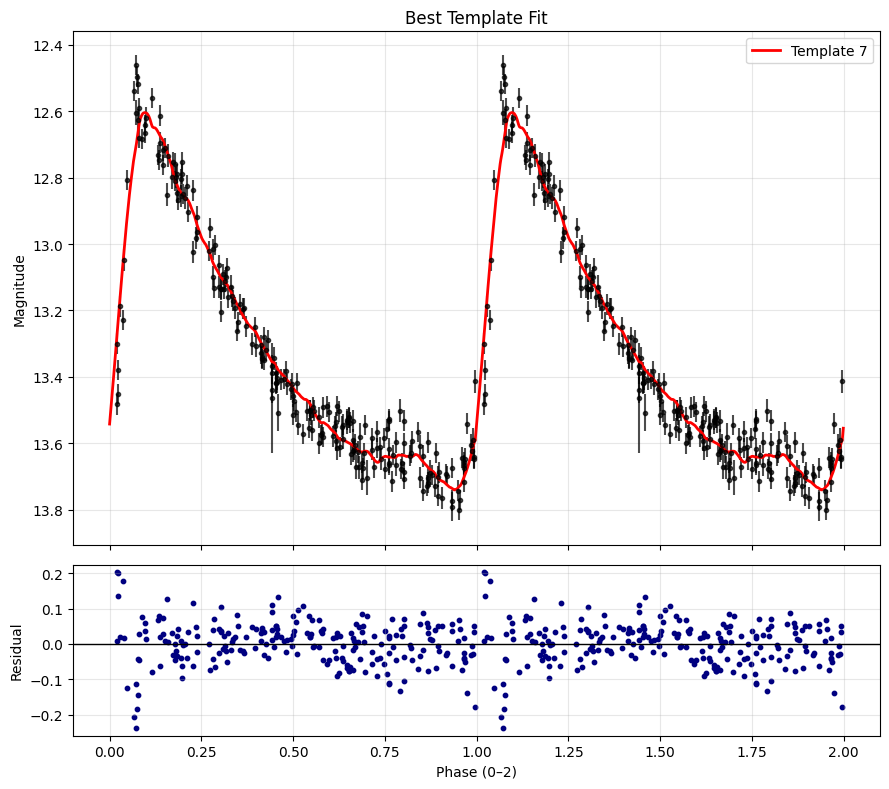

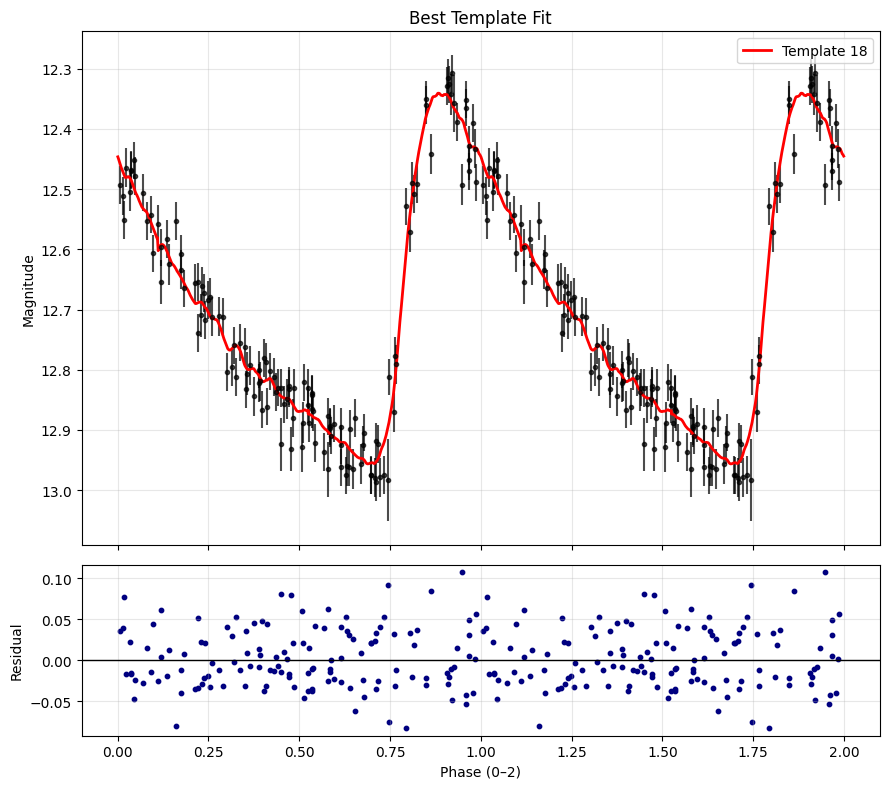

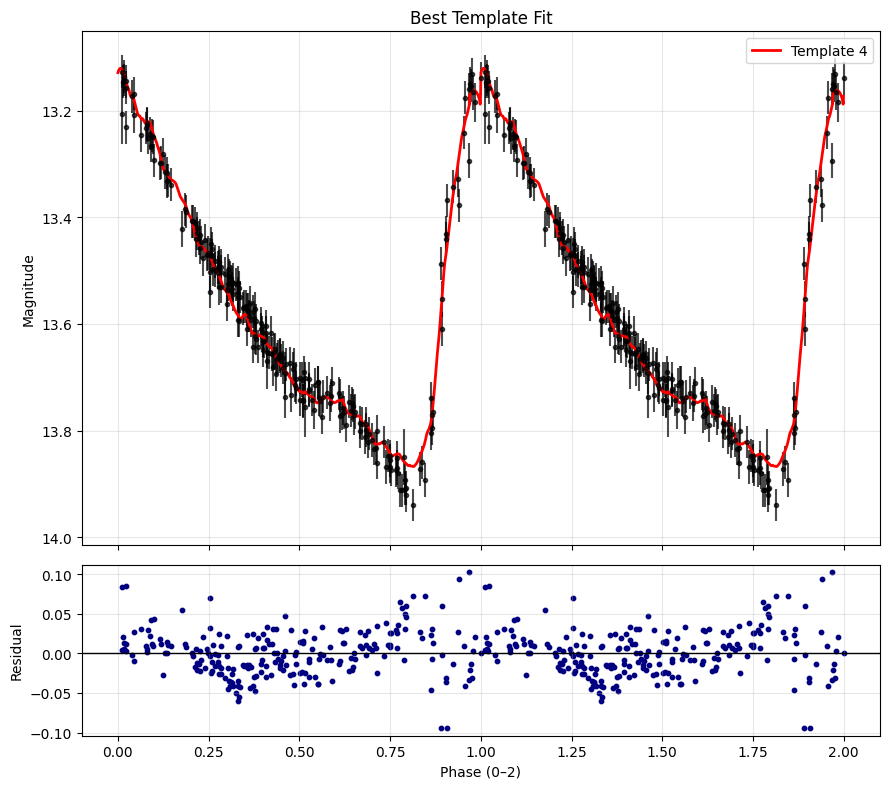

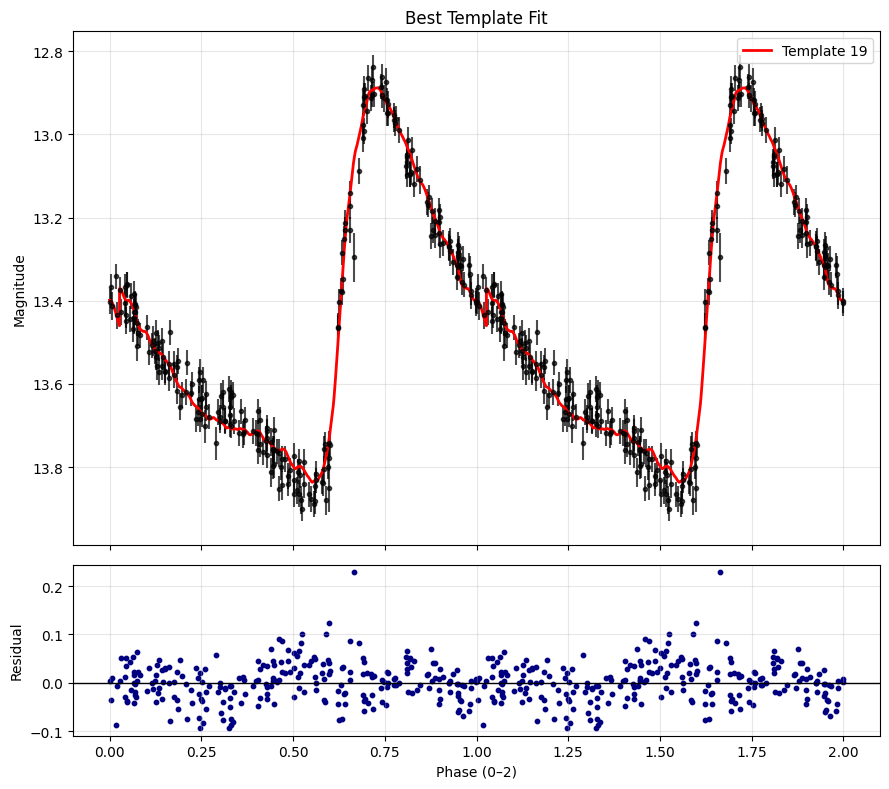

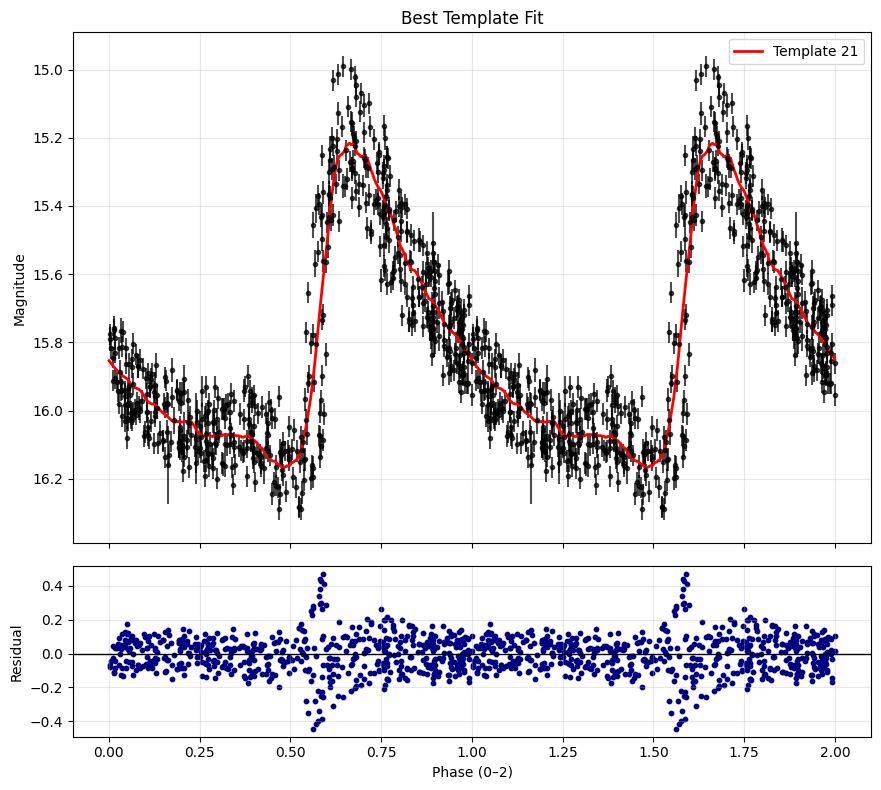

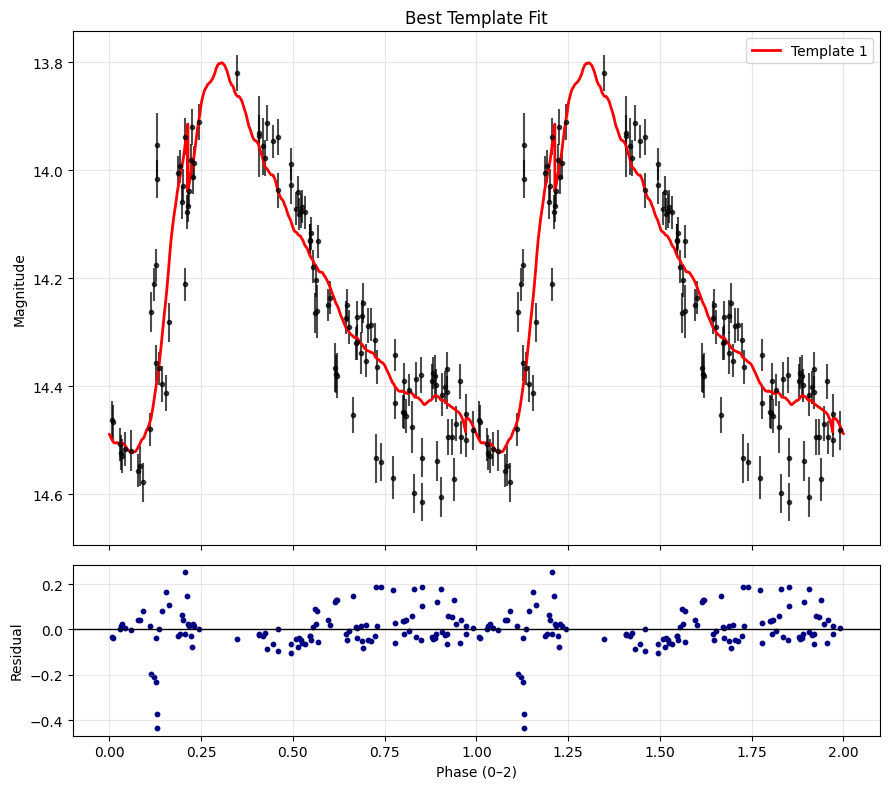

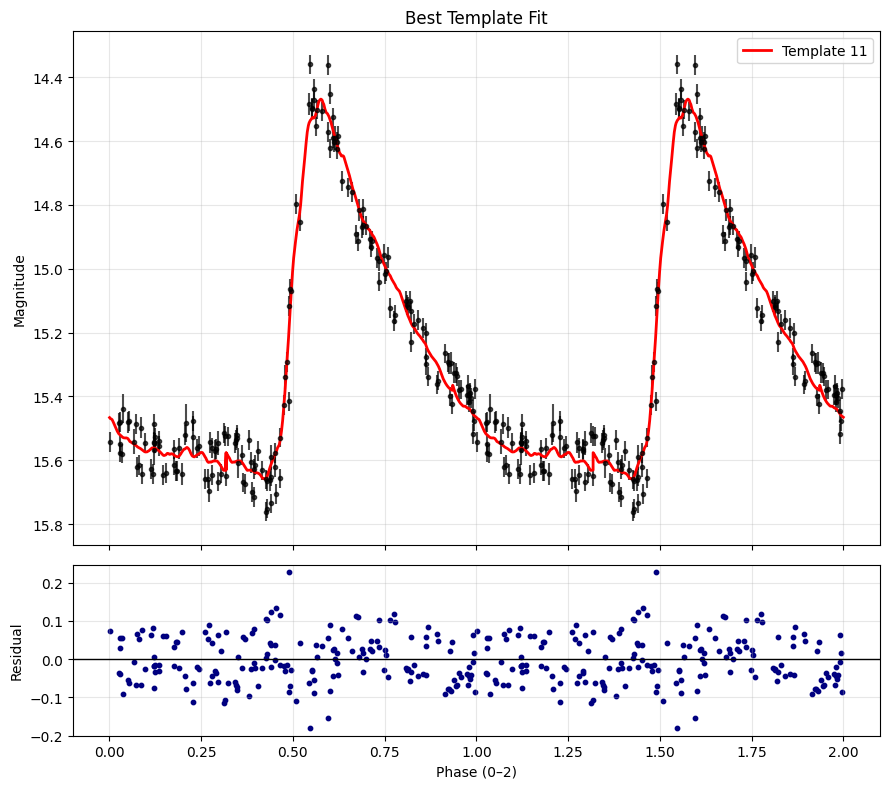

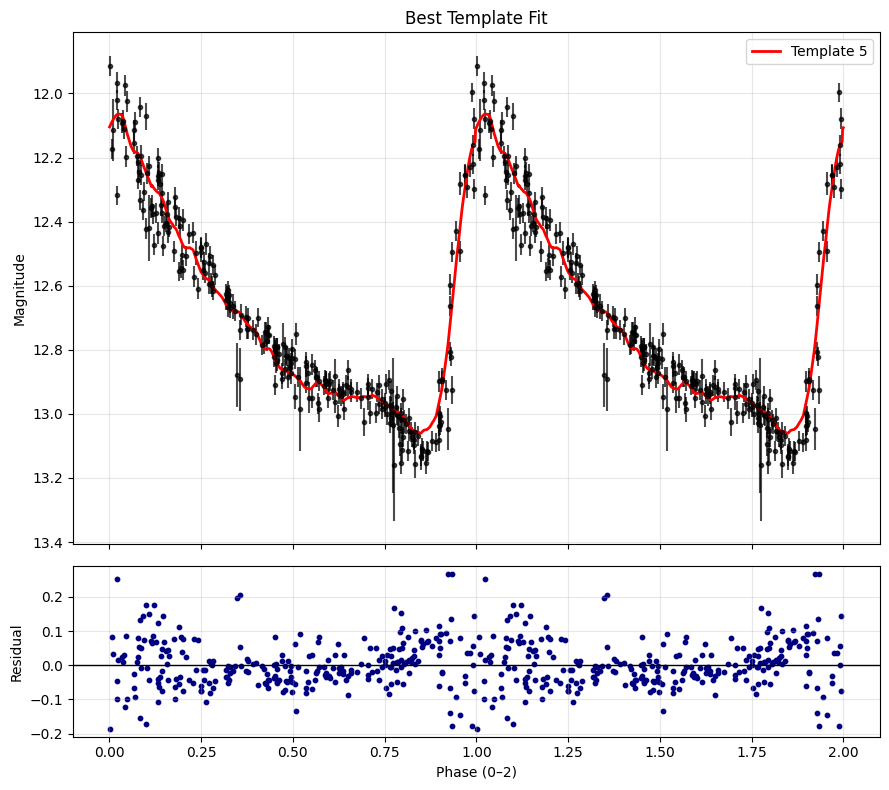

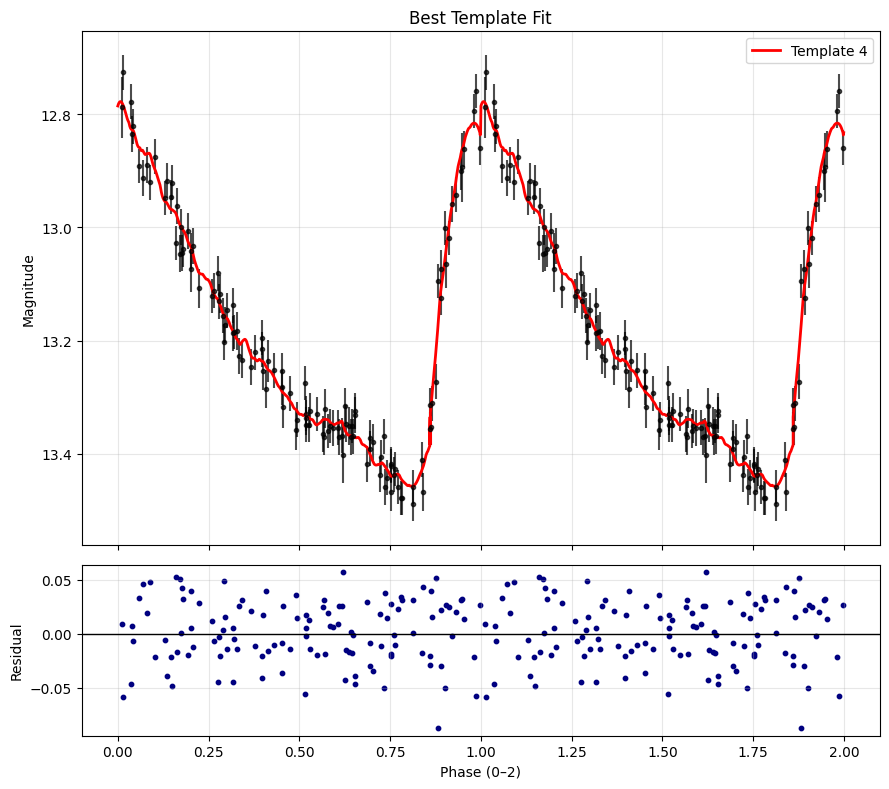

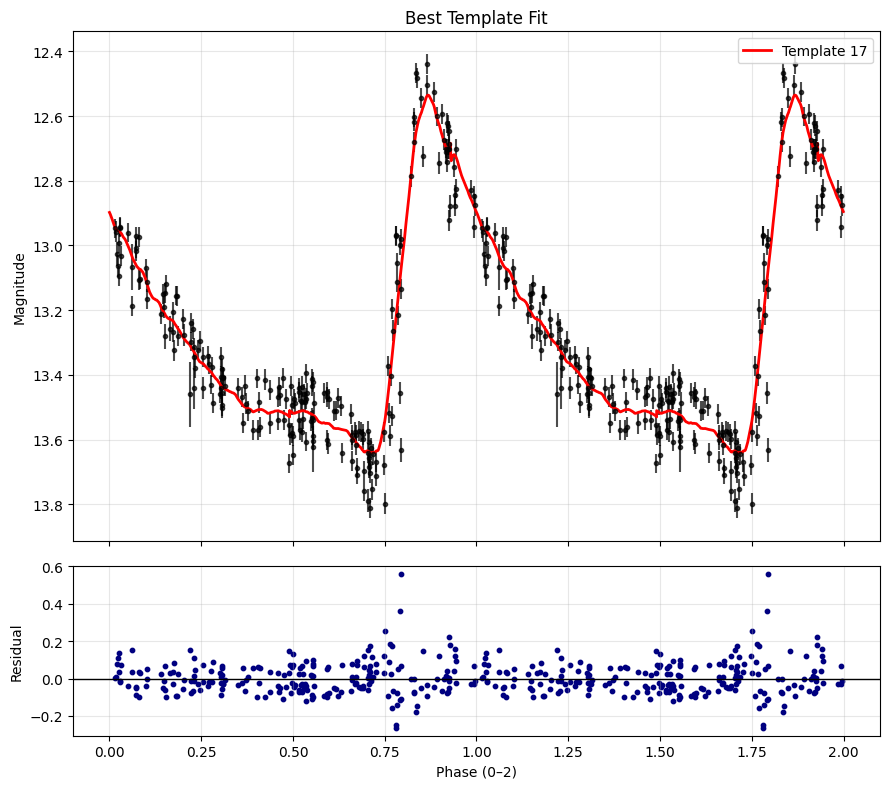

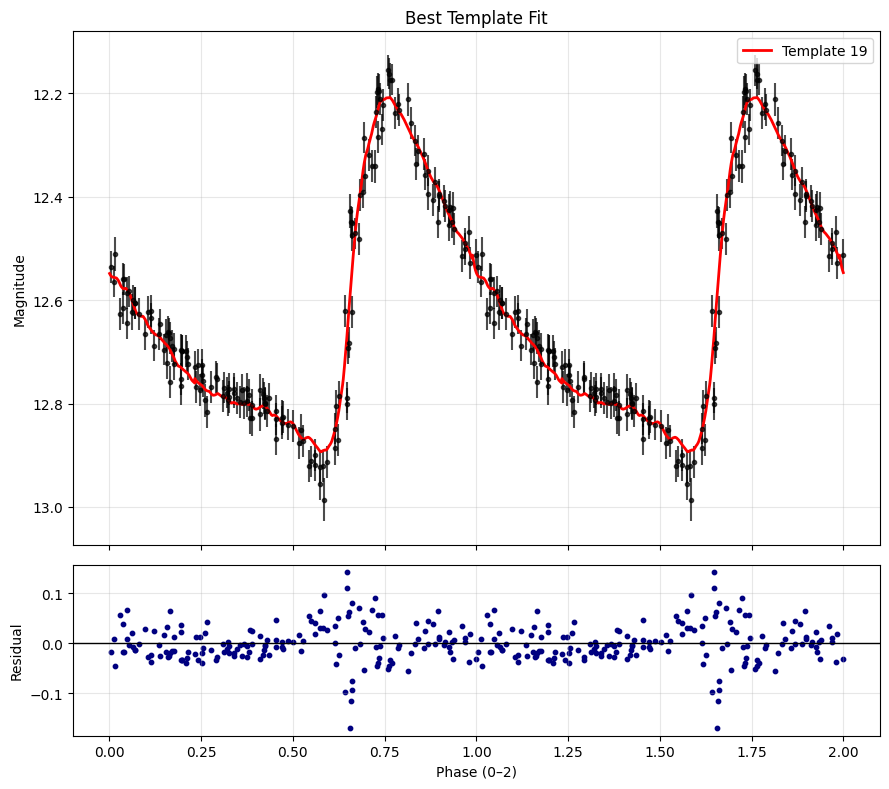

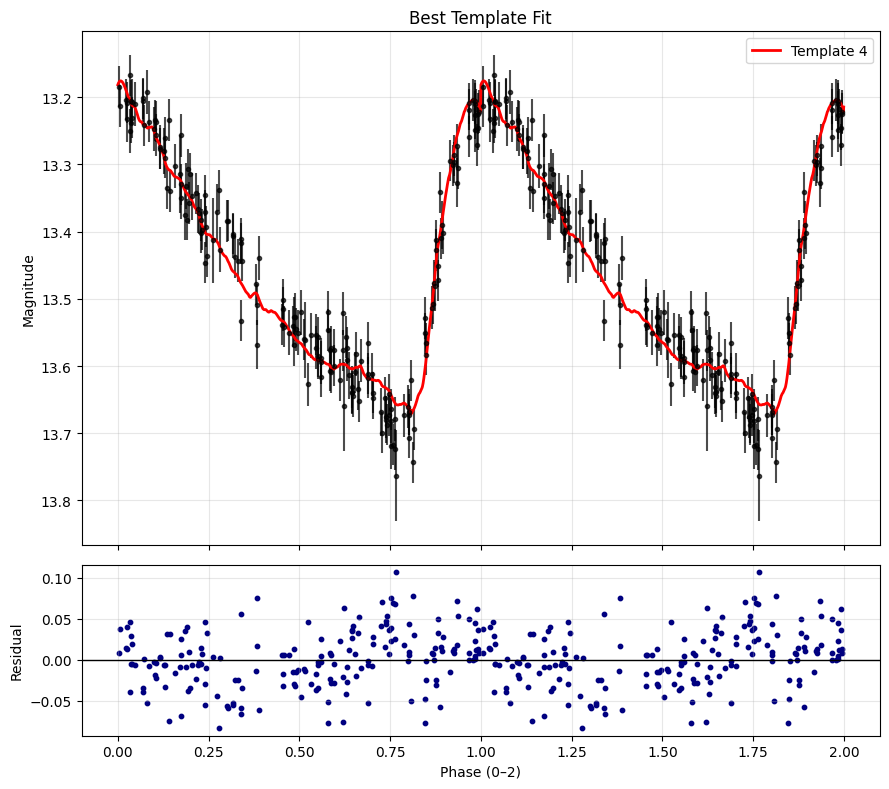

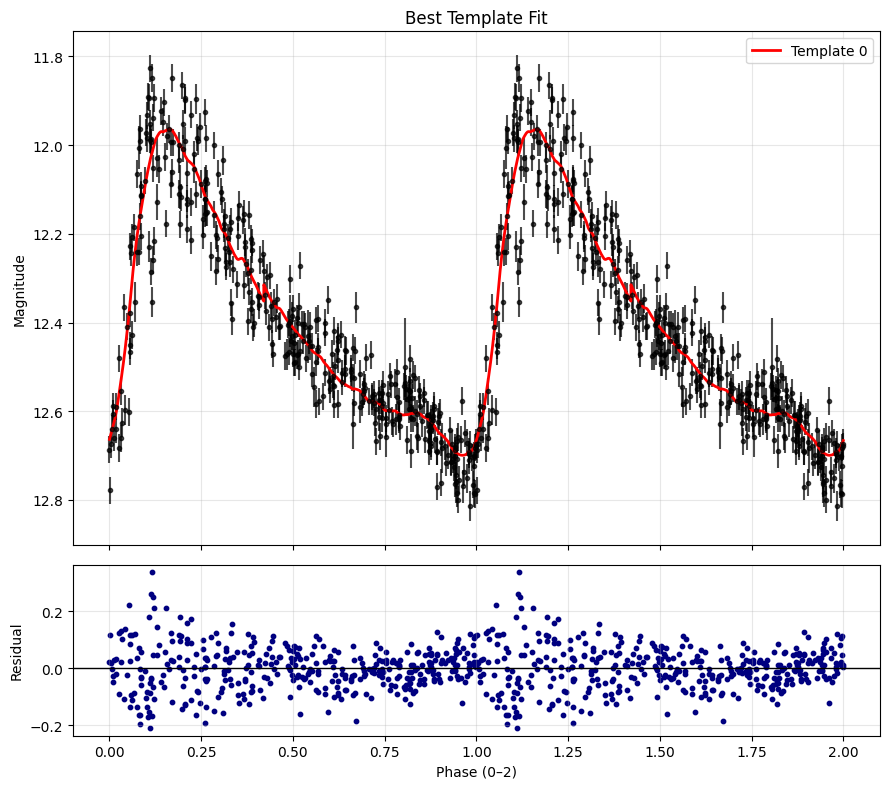

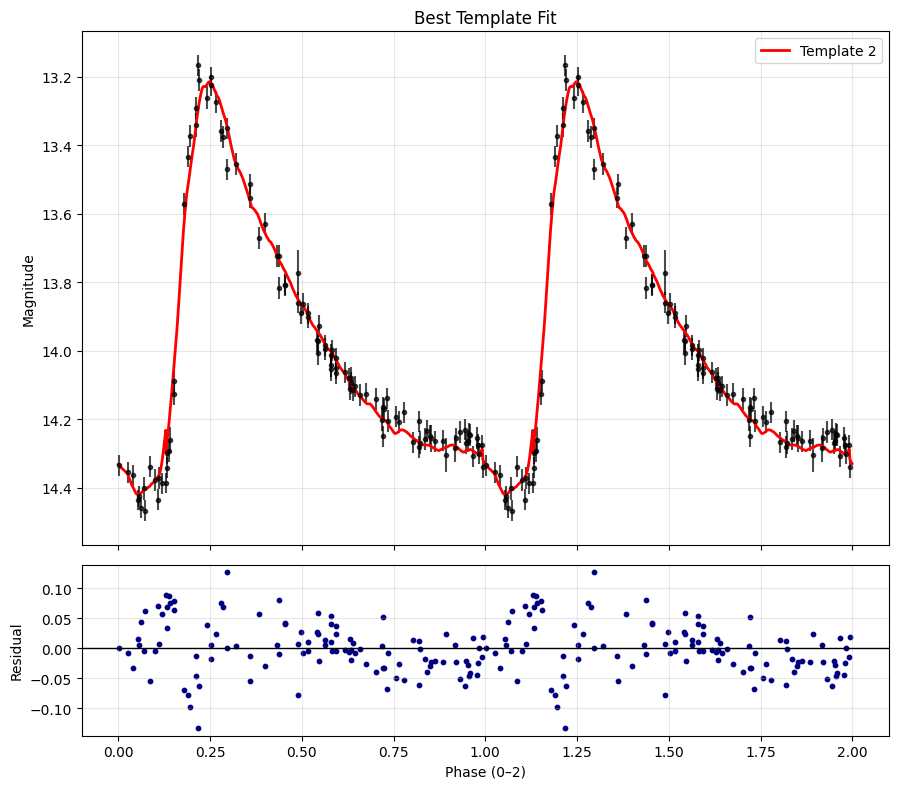

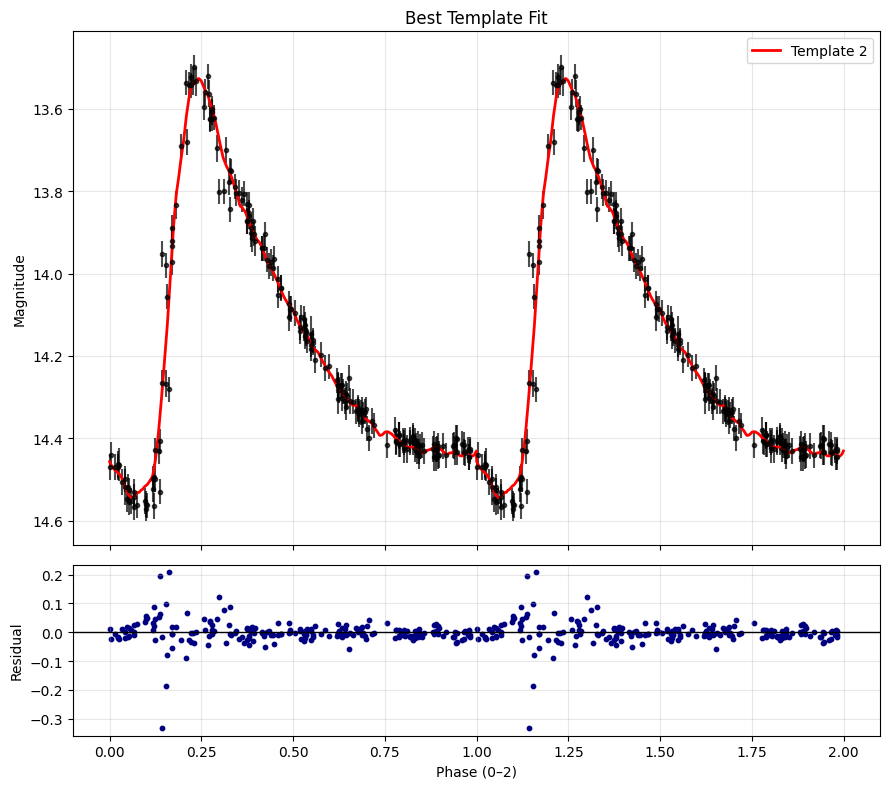

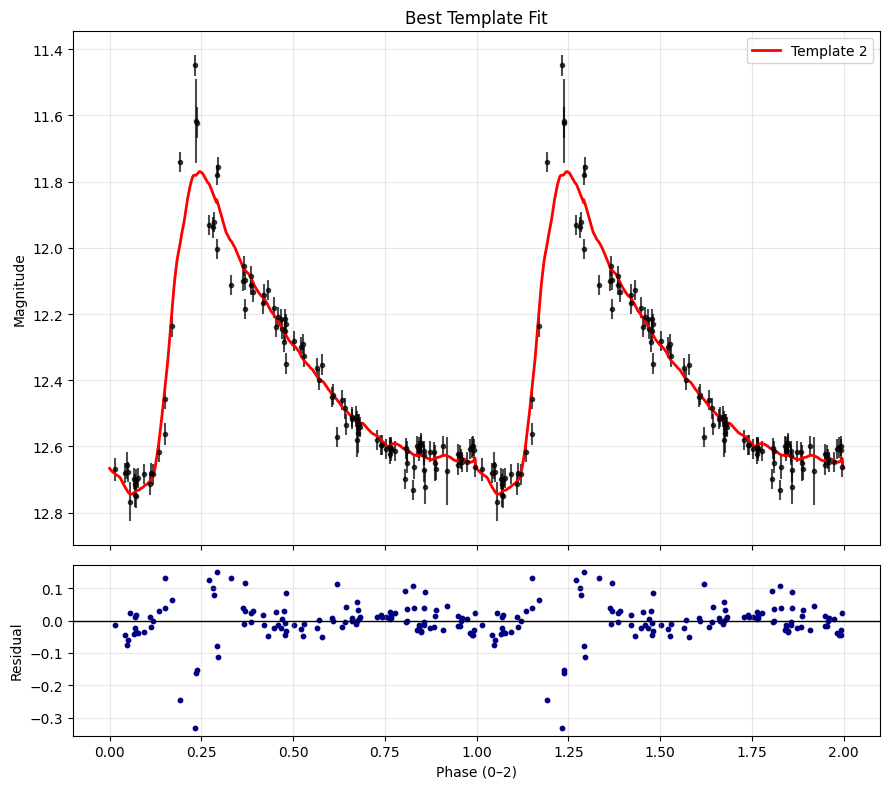

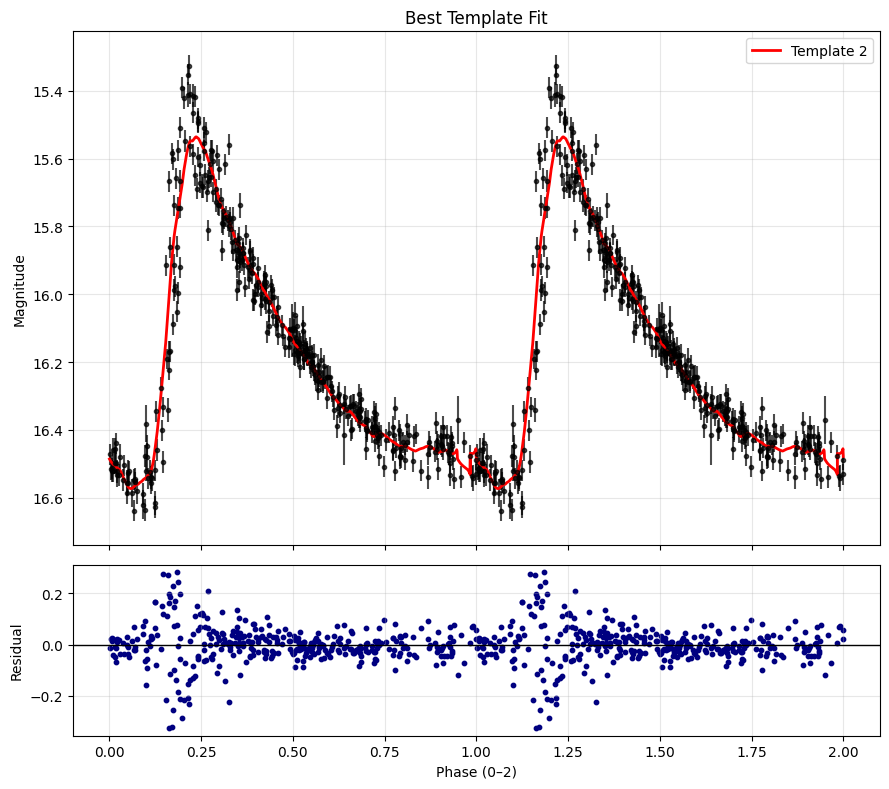

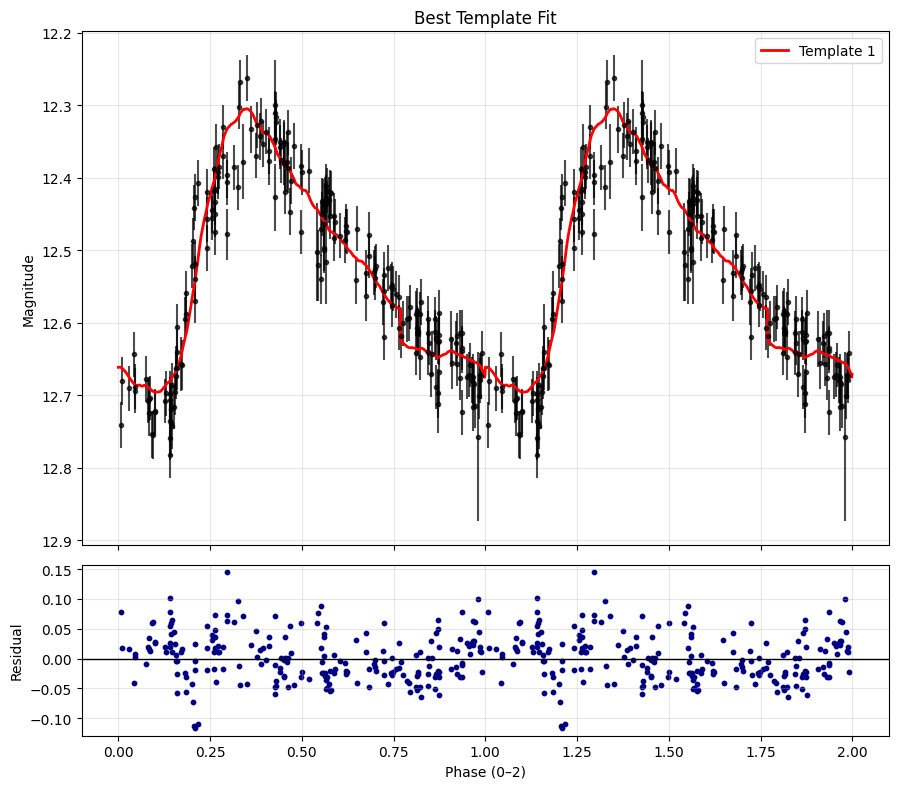

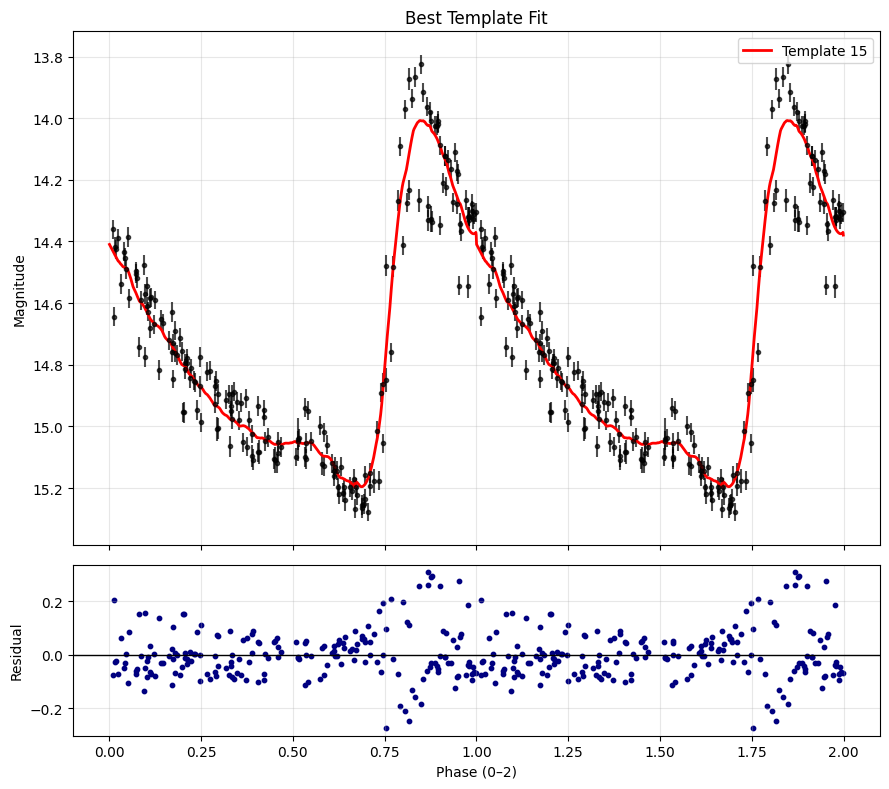

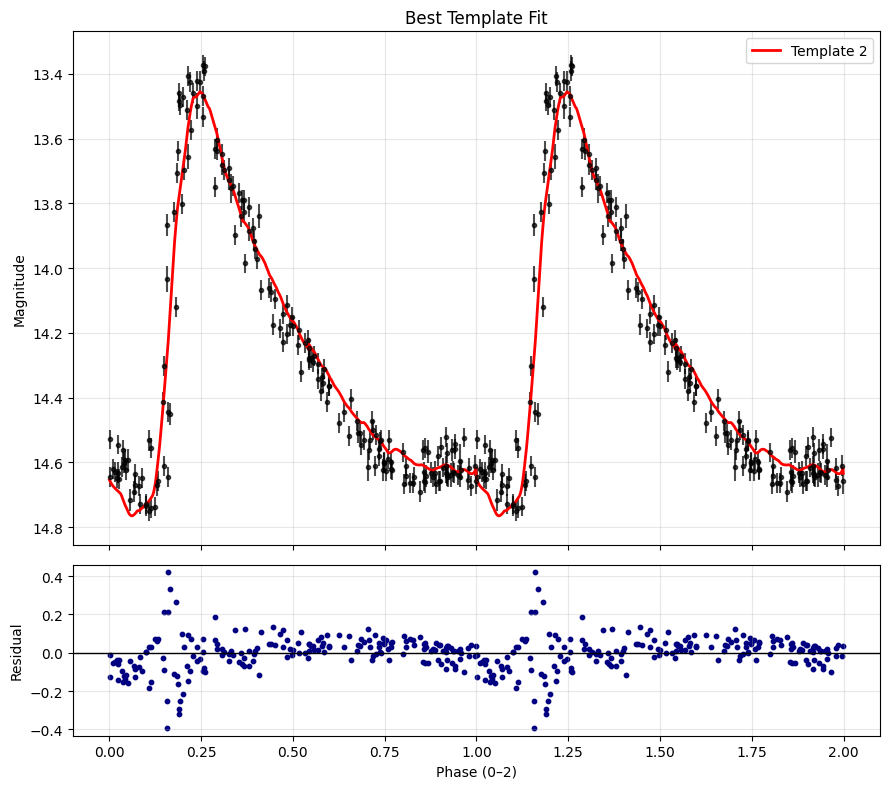

In [17]:
np.random.seed(42)
unique_ids = lc_df_good["star_id"].unique()
random_ids = np.random.choice(unique_ids, size=20, replace=False)

for i, sid in enumerate(random_ids, start=1):
    fit_and_plot_star(sid, lc_df_good)

## Example subset on sparse stars: 20 randomly generated curves

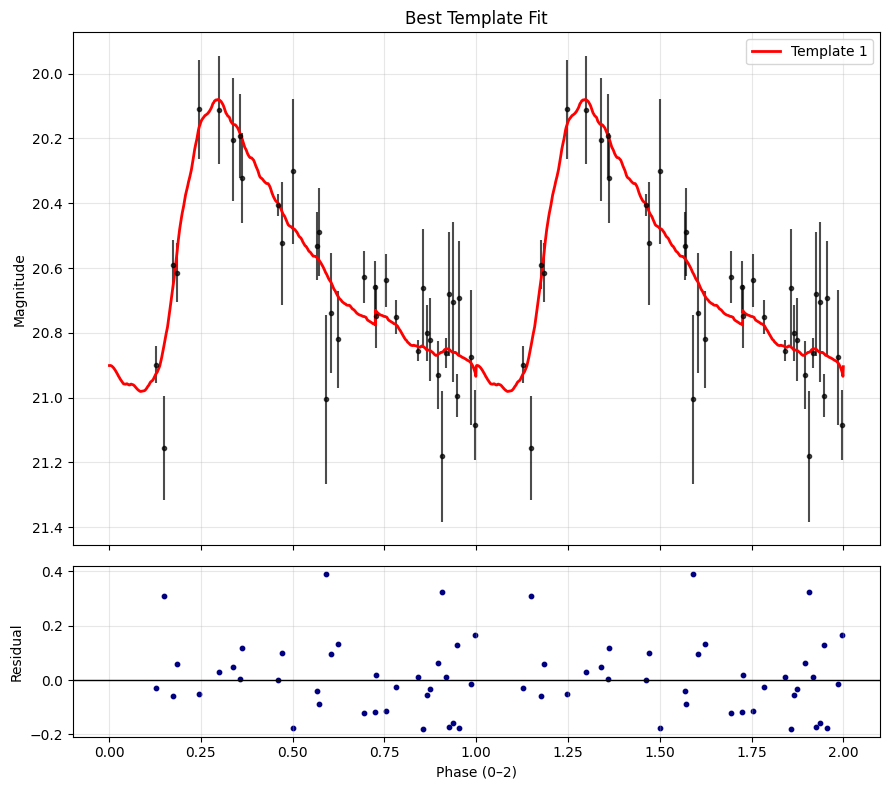

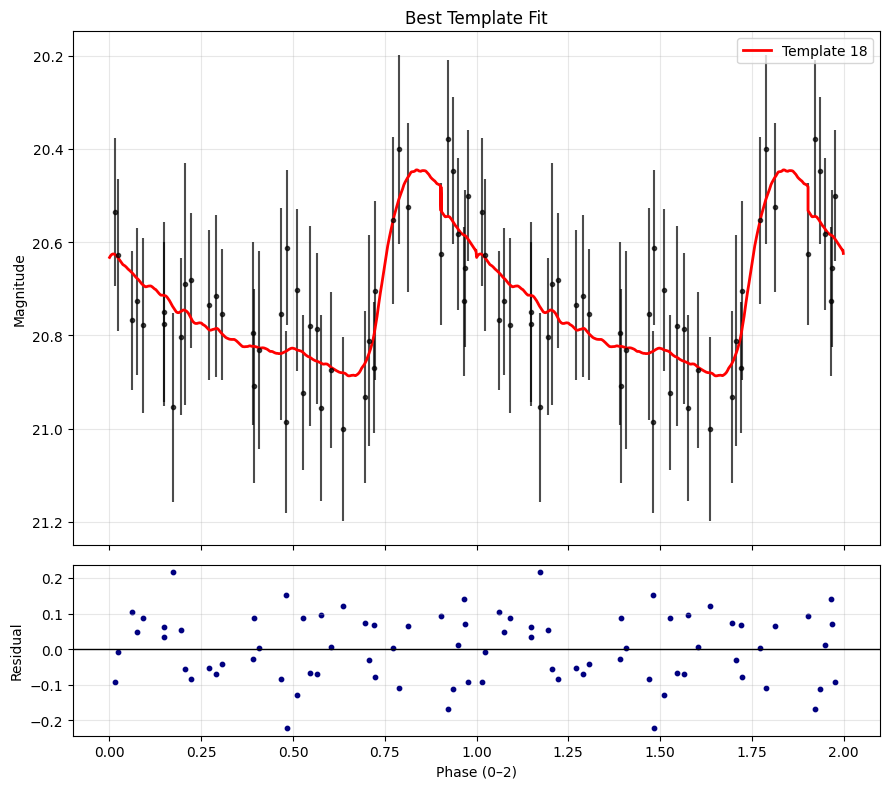

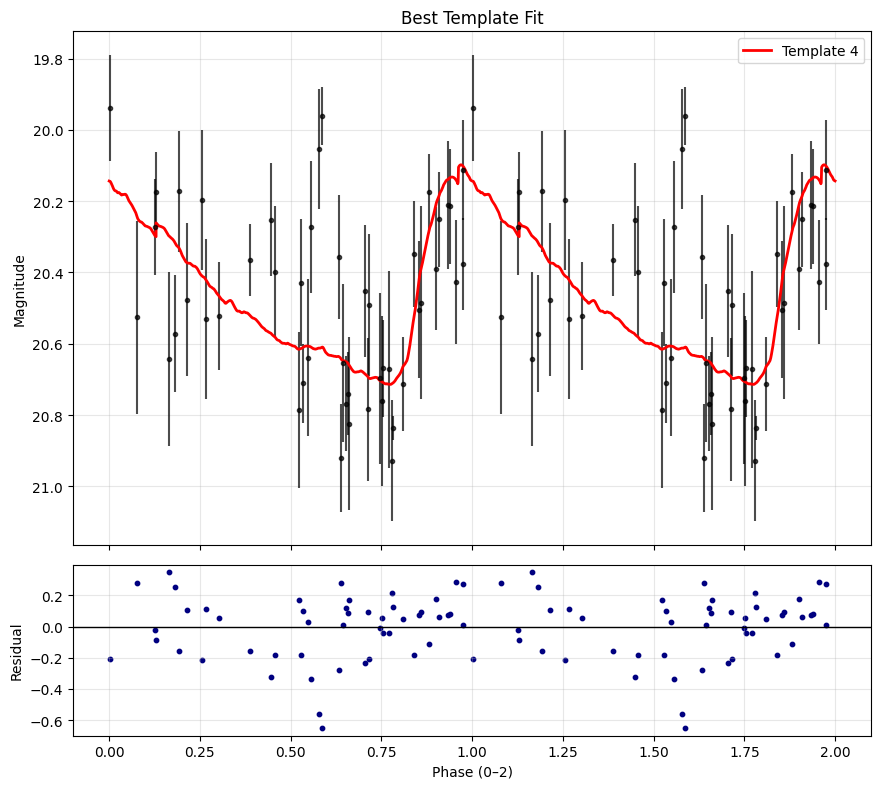

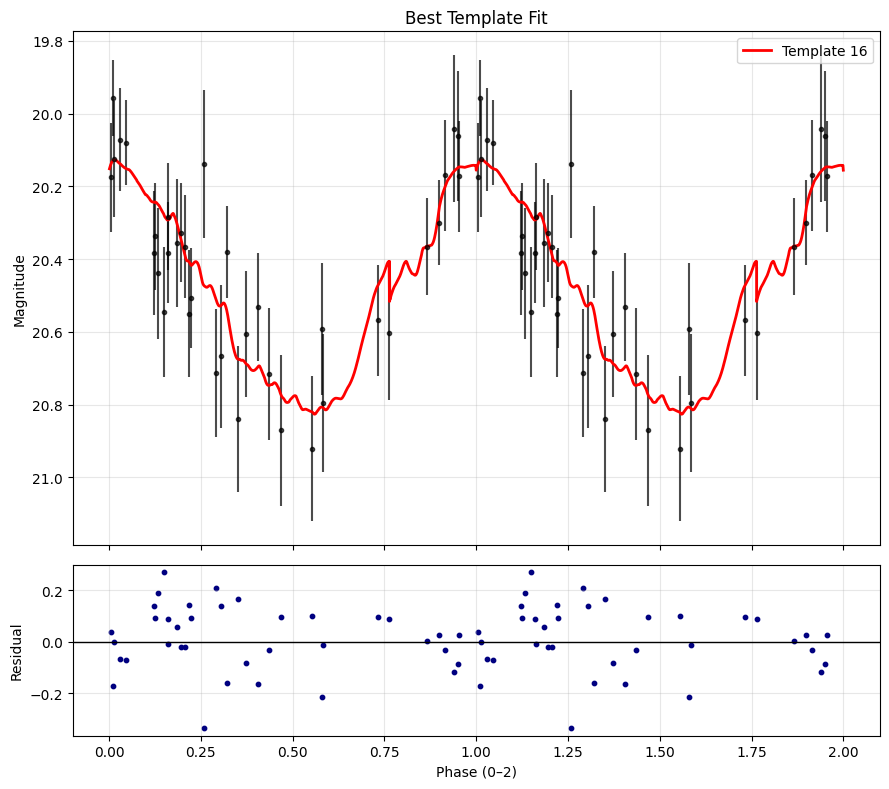

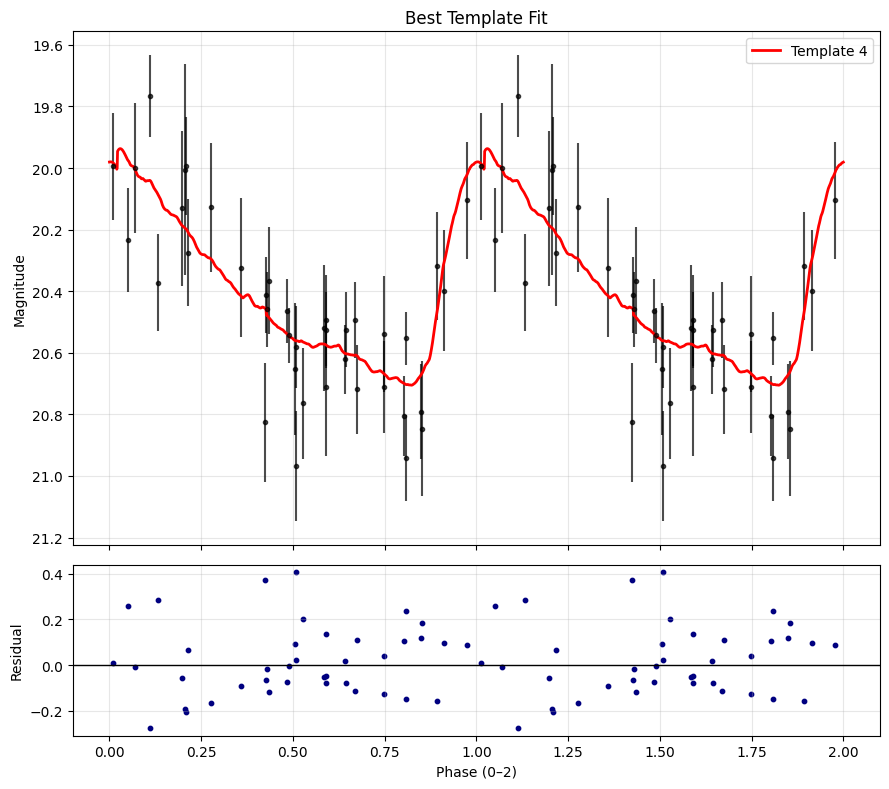

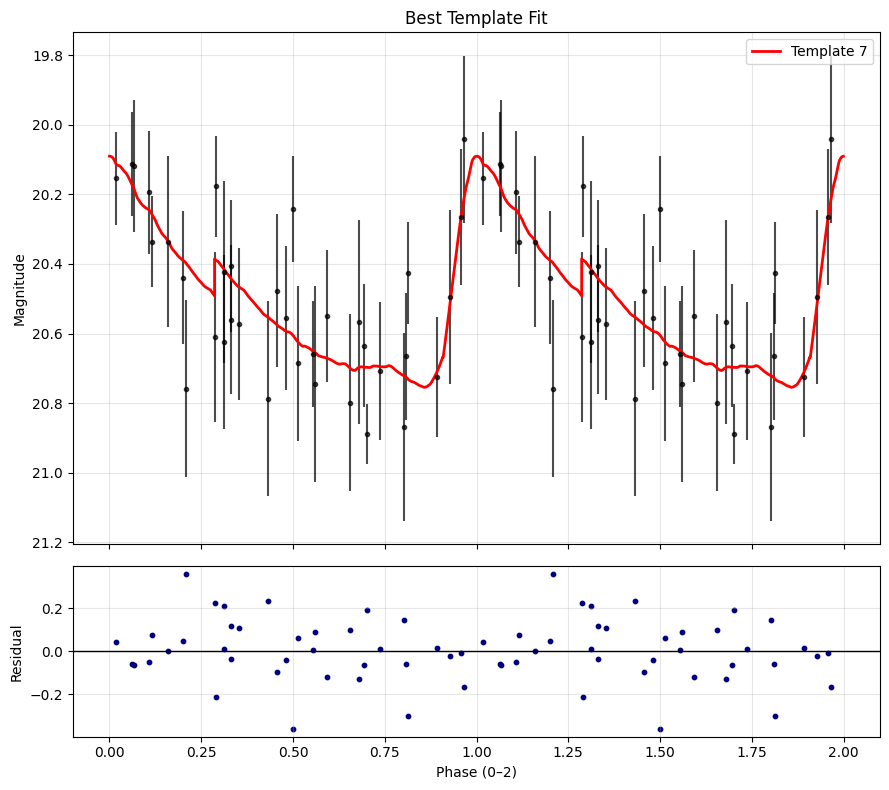

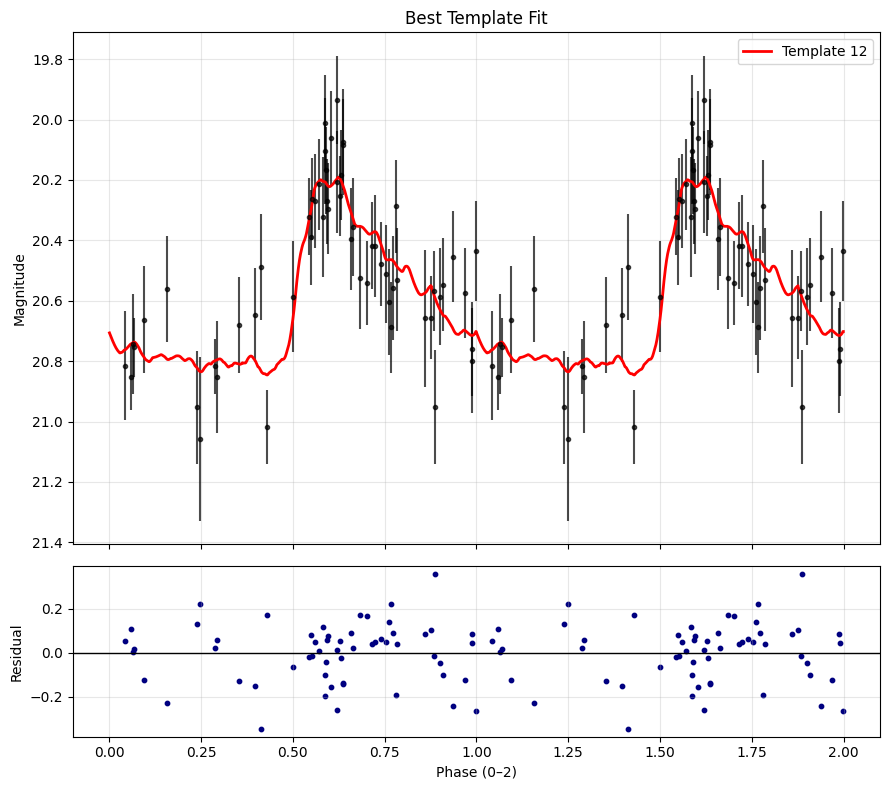

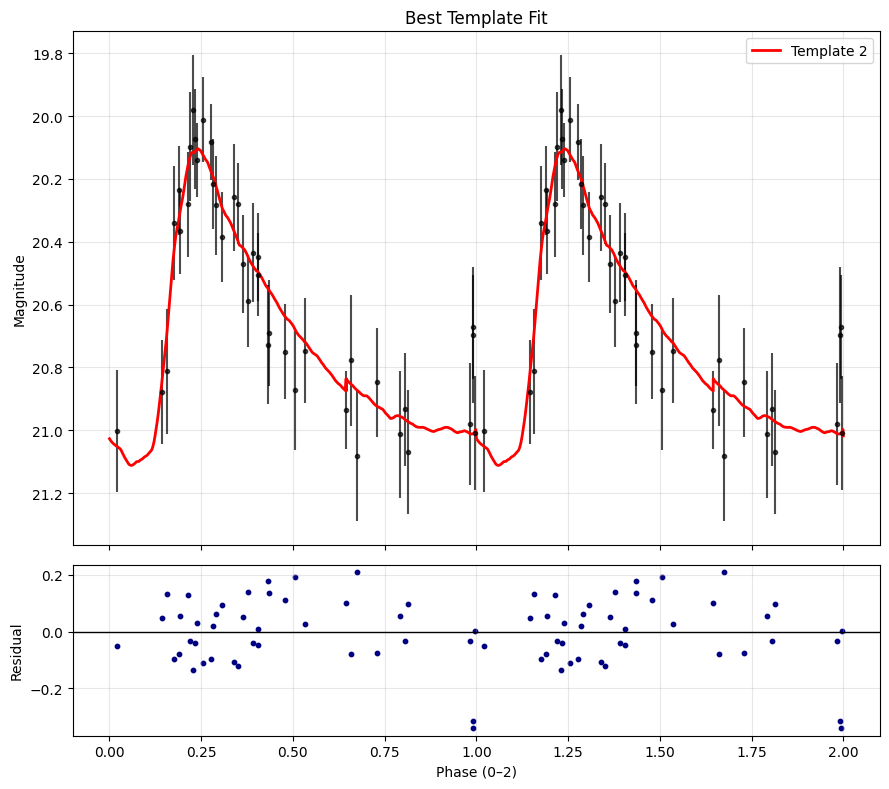

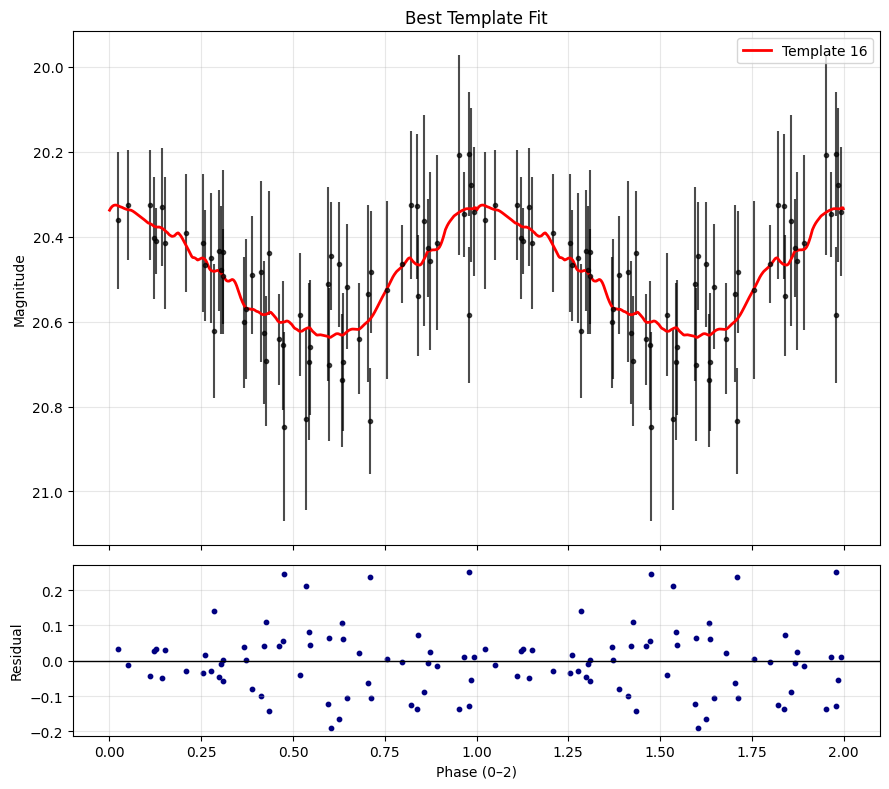

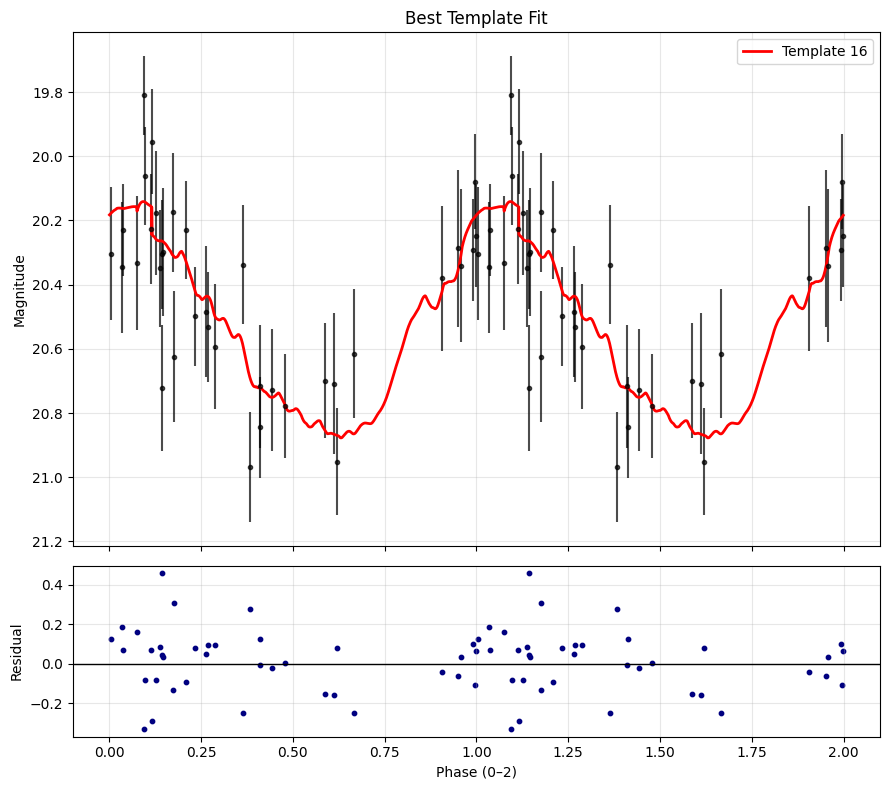

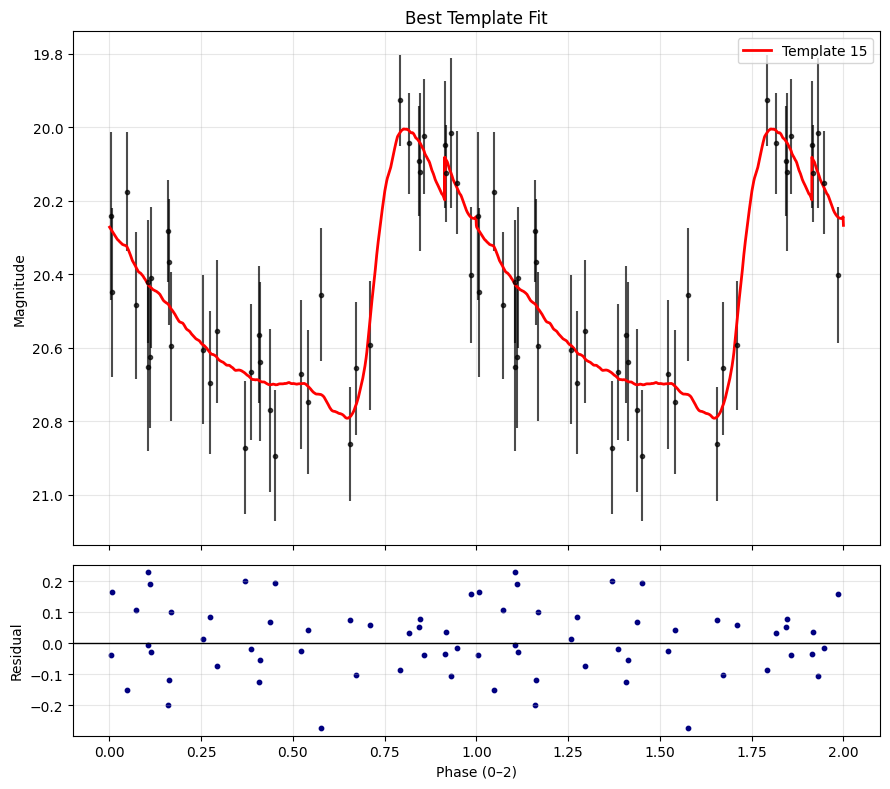

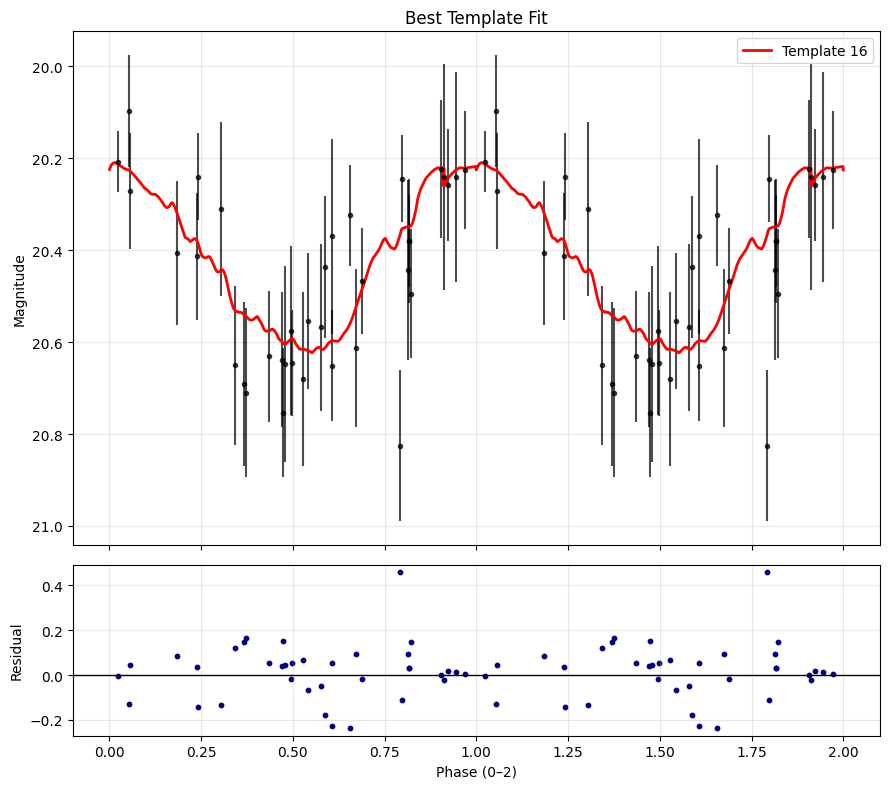

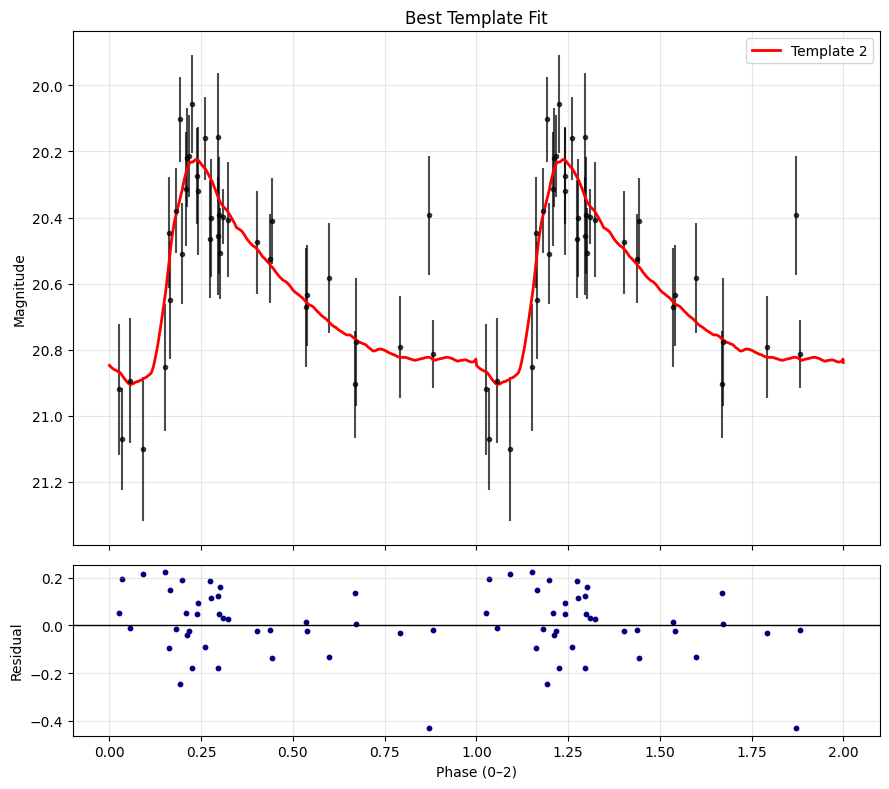

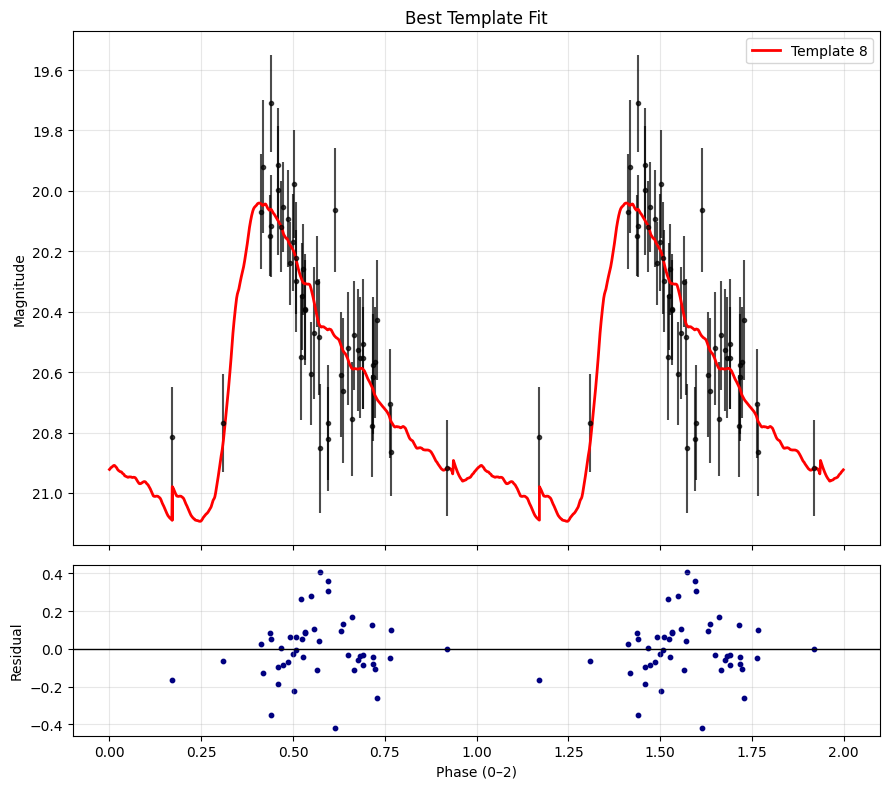

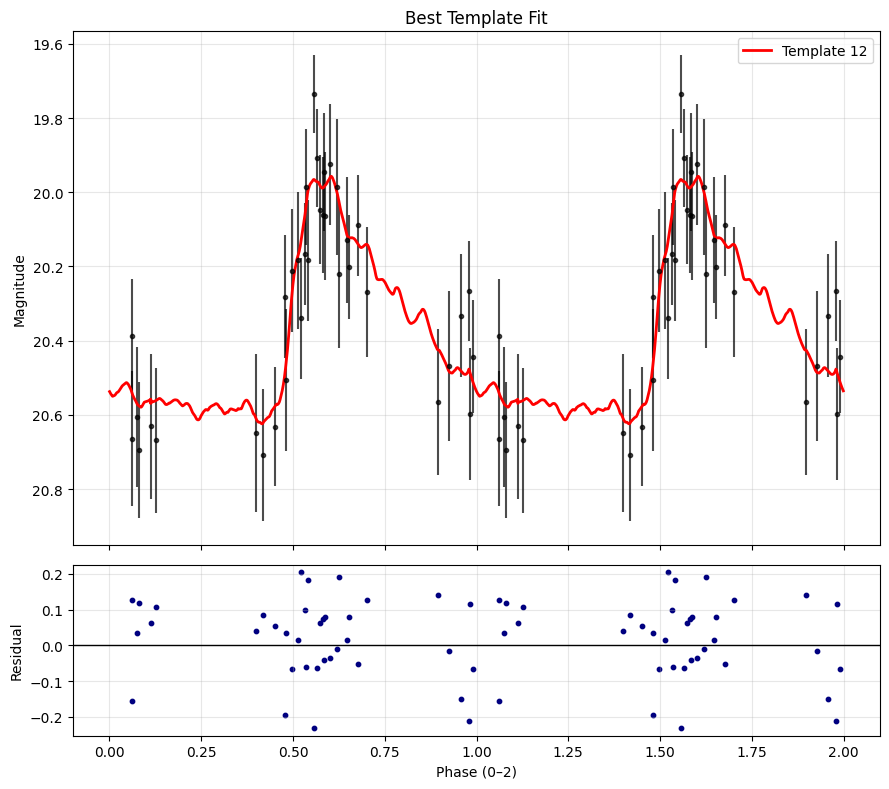

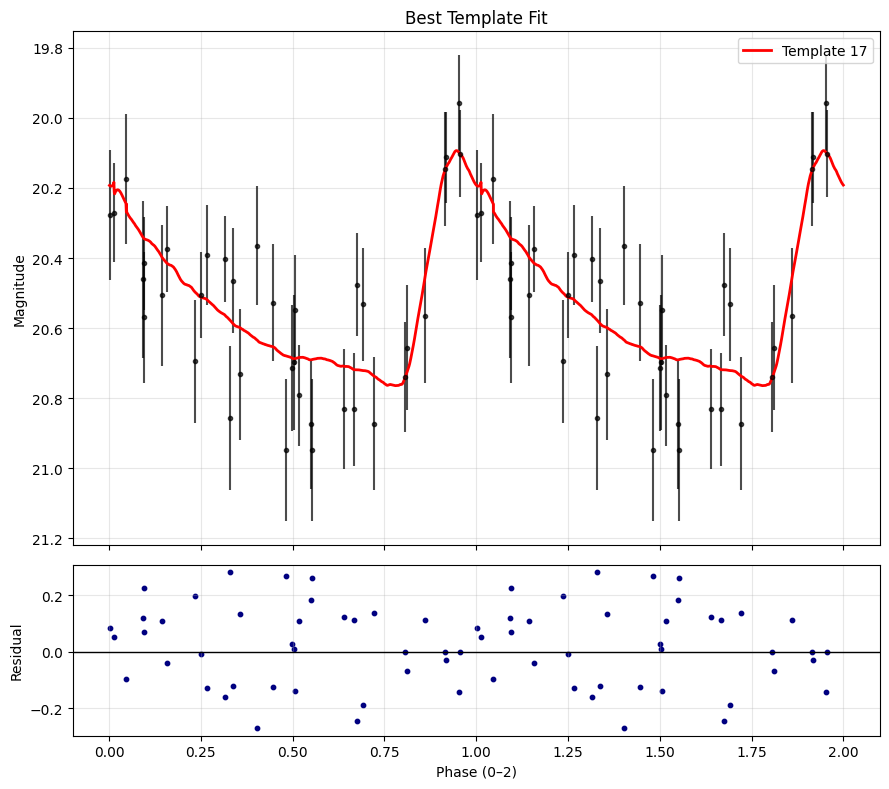

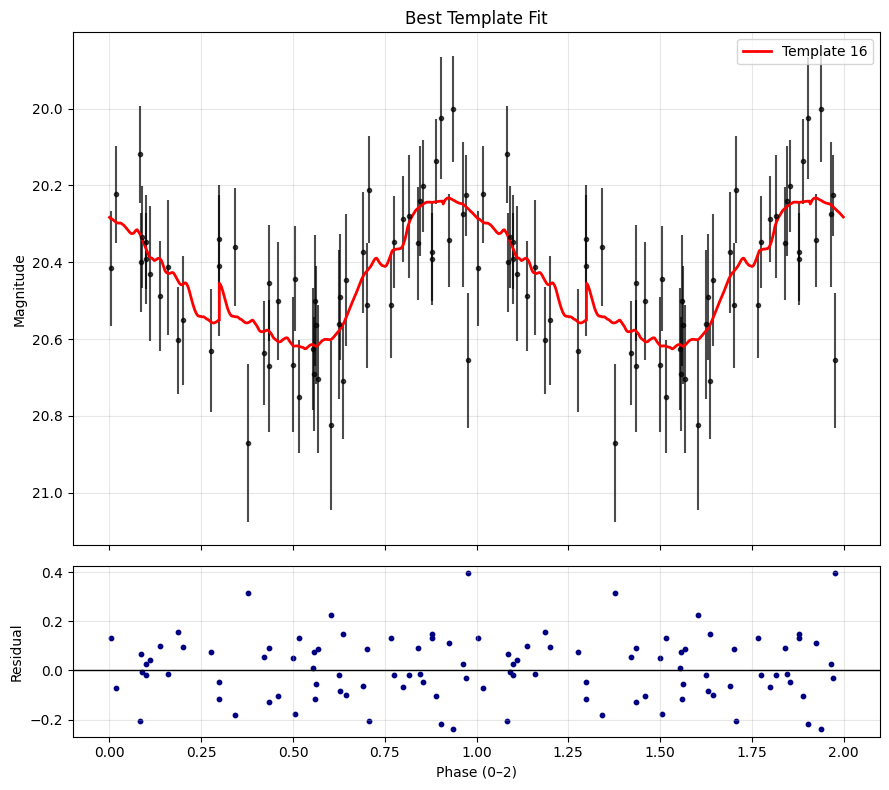

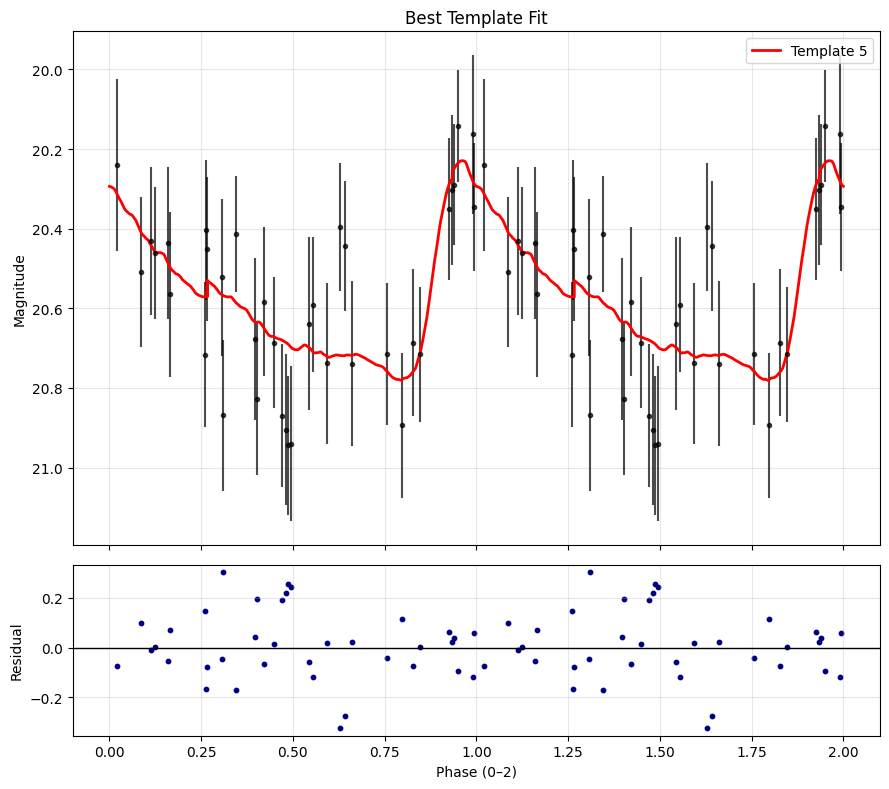

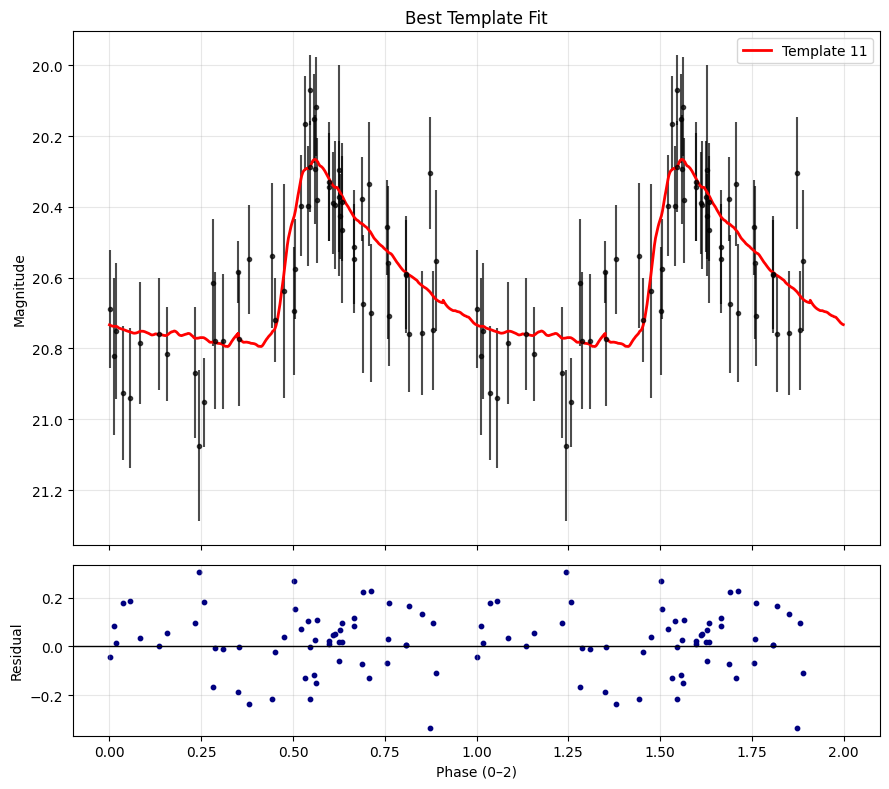

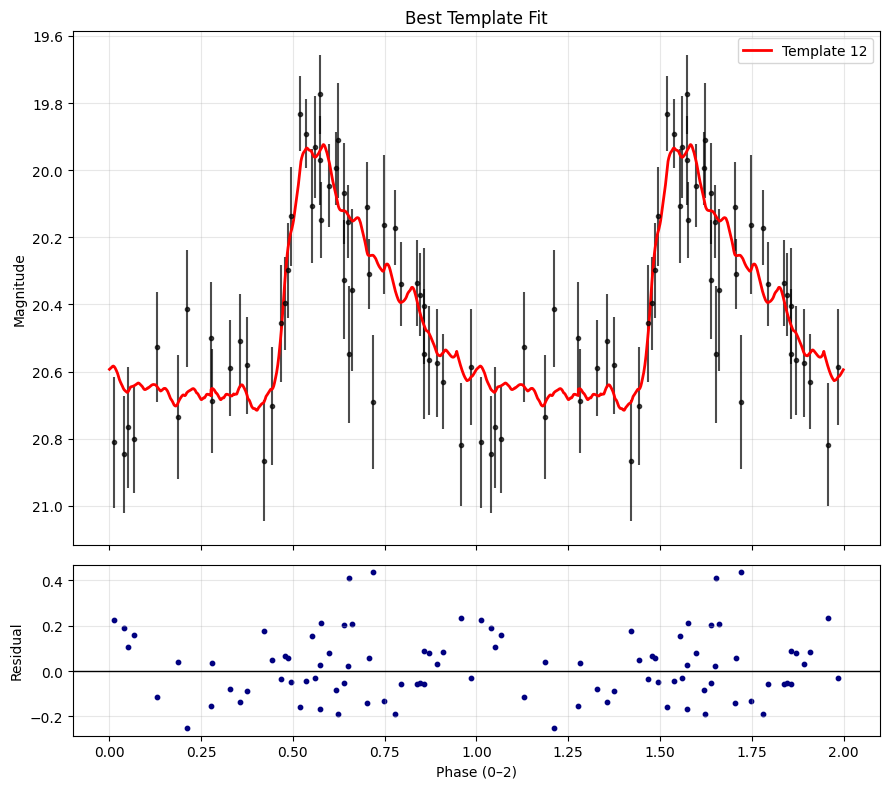

In [18]:
np.random.seed(42)
unique_ids = lc_df_bad["star_id"].unique()
random_ids = np.random.choice(unique_ids, size=20, replace=False)

for i, sid in enumerate(random_ids, start=1):
    fit_and_plot_star(sid, lc_df_bad)

# Continuous Template Fitting: Convolutional Autoencoder (CAE)

### Imports 

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize
from scipy.signal import savgol_filter

### Star preprocessing: phase-fold, align to minimum light, interpolate, smooth, normalize

In [23]:
def preprocess_star(time, mag, period, n_phase=1000):
    phase = ((time - time.min()) / period) % 1.0
    idx = np.argsort(phase)
    phase = phase[idx]
    mag   = mag[idx]

    i_min = np.argmin(mag)
    phase = np.roll(phase, -i_min)
    mag   = np.roll(mag,  -i_min)

    order = np.argsort(phase)
    phase = phase[order]
    mag   = mag[order]

    phase_grid = np.linspace(0.0, 1.0, n_phase, endpoint=False)
    mag_interp = np.interp(phase_grid, phase, mag,
                           left=mag[0], right=mag[-1])

    mag_smooth = savgol_filter(mag_interp, 21, 3) #same as with discrete templates but with a less strict Savgol filter 

    mu = mag_smooth.mean()
    sigma = mag_smooth.std()
    mag_norm = (mag_smooth - mu) / sigma

    return phase_grid, mag_norm

In [24]:
X_real = []
real_star_ids = []

for sid, g in lc_df_good.groupby("star_id"):
    if sid not in selected_ids:
        continue

    t = g["time"].values
    m = g["mag"].values
    P = g["period"].iloc[0]

    _, curve = preprocess_star(t, m, P, n_phase=1000)
    X_real.append(curve)
    real_star_ids.append(sid)

X_real = np.vstack(X_real).astype(np.float32)
print("AE training set shape:", X_real.shape)

AE training set shape: (418, 1000)


### Training CAE on subset of 418 'template stars' 

Utilized templates from https://github.com/udacity/deep-learning-v2-pytorch/blob/master/autoencoder/convolutional-autoencoder/Convolutional_Autoencoder_Solution.ipynb and https://www.geeksforgeeks.org/machine-learning/implement-convolutional-autoencoder-in-pytorch-with-cuda/

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
def random_roll(arr):
    k = np.random.randint(len(arr))
    return np.roll(arr, k)    #so the CAE will memorize the shape rather than the positions

class TemplateDataset(Dataset):
    def __init__(self, templates_array, augment=True):
        self.templates = templates_array
        self.augment = augment
    def __len__(self):
        return self.templates.shape[0]
    def __getitem__(self, idx):
        x = self.templates[idx]
        if self.augment:
            x = random_roll(x)
        x = torch.from_numpy(x).float().unsqueeze(0)
        return x

train_templates = X_real 

dataset = TemplateDataset(train_templates, augment=True)
loader  = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

In [27]:
class Conv1DRRLAE(nn.Module):
    def __init__(self, input_length, latent_dim=6):
        super().__init__()
        self.input_length = input_length
        self.latent_dim   = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=9, stride=2, padding=4, padding_mode='circular'), ### using circular padding as RRL are periodic
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=9, stride=2, padding=4, padding_mode='circular'),
            nn.ReLU(),
            nn.Conv1d(32, 48, kernel_size=9, stride=2, padding=4, padding_mode='circular'),
            nn.ReLU())

        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_length)
            enc_out = self.encoder(dummy)
        self.enc_channels = enc_out.shape[1]
        self.enc_length   = enc_out.shape[2]
        self.enc_flat_dim = self.enc_channels * self.enc_length
        
        print("Encoded shape:", self.enc_channels, "x", self.enc_length, "→", self.enc_flat_dim)

        self.fc_mu     = nn.Linear(self.enc_flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.enc_flat_dim)


        def up_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Upsample(scale_factor=2, mode='nearest'),
                nn.Conv1d(in_ch, out_ch, kernel_size=9, padding=4, padding_mode='circular'), ## using circular padding as RRL are periodic
                nn.ReLU())

        self.dec_up1 = up_block(self.enc_channels, 32)
        self.dec_up2 = up_block(32, 16)
        self.dec_final = nn.Conv1d(16, 1, kernel_size=9, padding=4, padding_mode='circular')


    def encode(self, x):
        h = self.encoder(x)
        h_flat = h.view(x.size(0), -1)
        z = self.fc_mu(h_flat)
        return z

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(z.size(0), self.enc_channels, self.enc_length)
        h = self.dec_up1(h)
        h = self.dec_up2(h)
        y = self.dec_final(h)

        if y.shape[-1] > self.input_length:
            y = y[..., :self.input_length]
        elif y.shape[-1] < self.input_length:
            y = F.interpolate(y, size=self.input_length, mode="linear", align_corners=False)
        return y

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z)
        return recon, z

LATENT_DIM = 6
L = X_real.shape[1]
model = Conv1DRRLAE(input_length=L, latent_dim=LATENT_DIM).to(device)
print(model)

Encoded shape: 48 x 125 → 6000
Conv1DRRLAE(
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(9,), stride=(2,), padding=(4,), padding_mode=circular)
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(9,), stride=(2,), padding=(4,), padding_mode=circular)
    (3): ReLU()
    (4): Conv1d(32, 48, kernel_size=(9,), stride=(2,), padding=(4,), padding_mode=circular)
    (5): ReLU()
  )
  (fc_mu): Linear(in_features=6000, out_features=6, bias=True)
  (fc_decode): Linear(in_features=6, out_features=6000, bias=True)
  (dec_up1): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv1d(48, 32, kernel_size=(9,), stride=(1,), padding=(4,), padding_mode=circular)
    (2): ReLU()
  )
  (dec_up2): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv1d(32, 16, kernel_size=(9,), stride=(1,), padding=(4,), padding_mode=circular)
    (2): ReLU()
  )
  (dec_final): Conv1d(16, 1, kernel_size=(9,), stride=(1,), padding=(4,), padding_mode=circular)

In [28]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss() #penalizes differences

EPOCHS = 200

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for batch in loader:
        batch = batch.to(device)

        noisy = batch + 0.01 * torch.randn_like(batch)

        recon, z = model(noisy)
        loss = criterion(recon, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch.size(0)

    epoch_loss = running_loss / len(dataset)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | loss = {epoch_loss:.6e}")

Epoch   1 | loss = 7.857556e-01
Epoch  10 | loss = 7.610865e-02
Epoch  20 | loss = 6.518350e-02
Epoch  30 | loss = 6.187390e-02
Epoch  40 | loss = 6.007522e-02
Epoch  50 | loss = 5.738432e-02
Epoch  60 | loss = 5.640072e-02
Epoch  70 | loss = 5.648264e-02
Epoch  80 | loss = 6.004495e-02
Epoch  90 | loss = 5.580580e-02
Epoch 100 | loss = 5.779626e-02
Epoch 110 | loss = 5.490793e-02
Epoch 120 | loss = 5.604192e-02
Epoch 130 | loss = 5.478859e-02
Epoch 140 | loss = 5.452435e-02
Epoch 150 | loss = 5.432233e-02
Epoch 160 | loss = 5.458424e-02
Epoch 170 | loss = 5.447815e-02
Epoch 180 | loss = 5.474059e-02
Epoch 190 | loss = 5.436264e-02
Epoch 200 | loss = 5.463013e-02


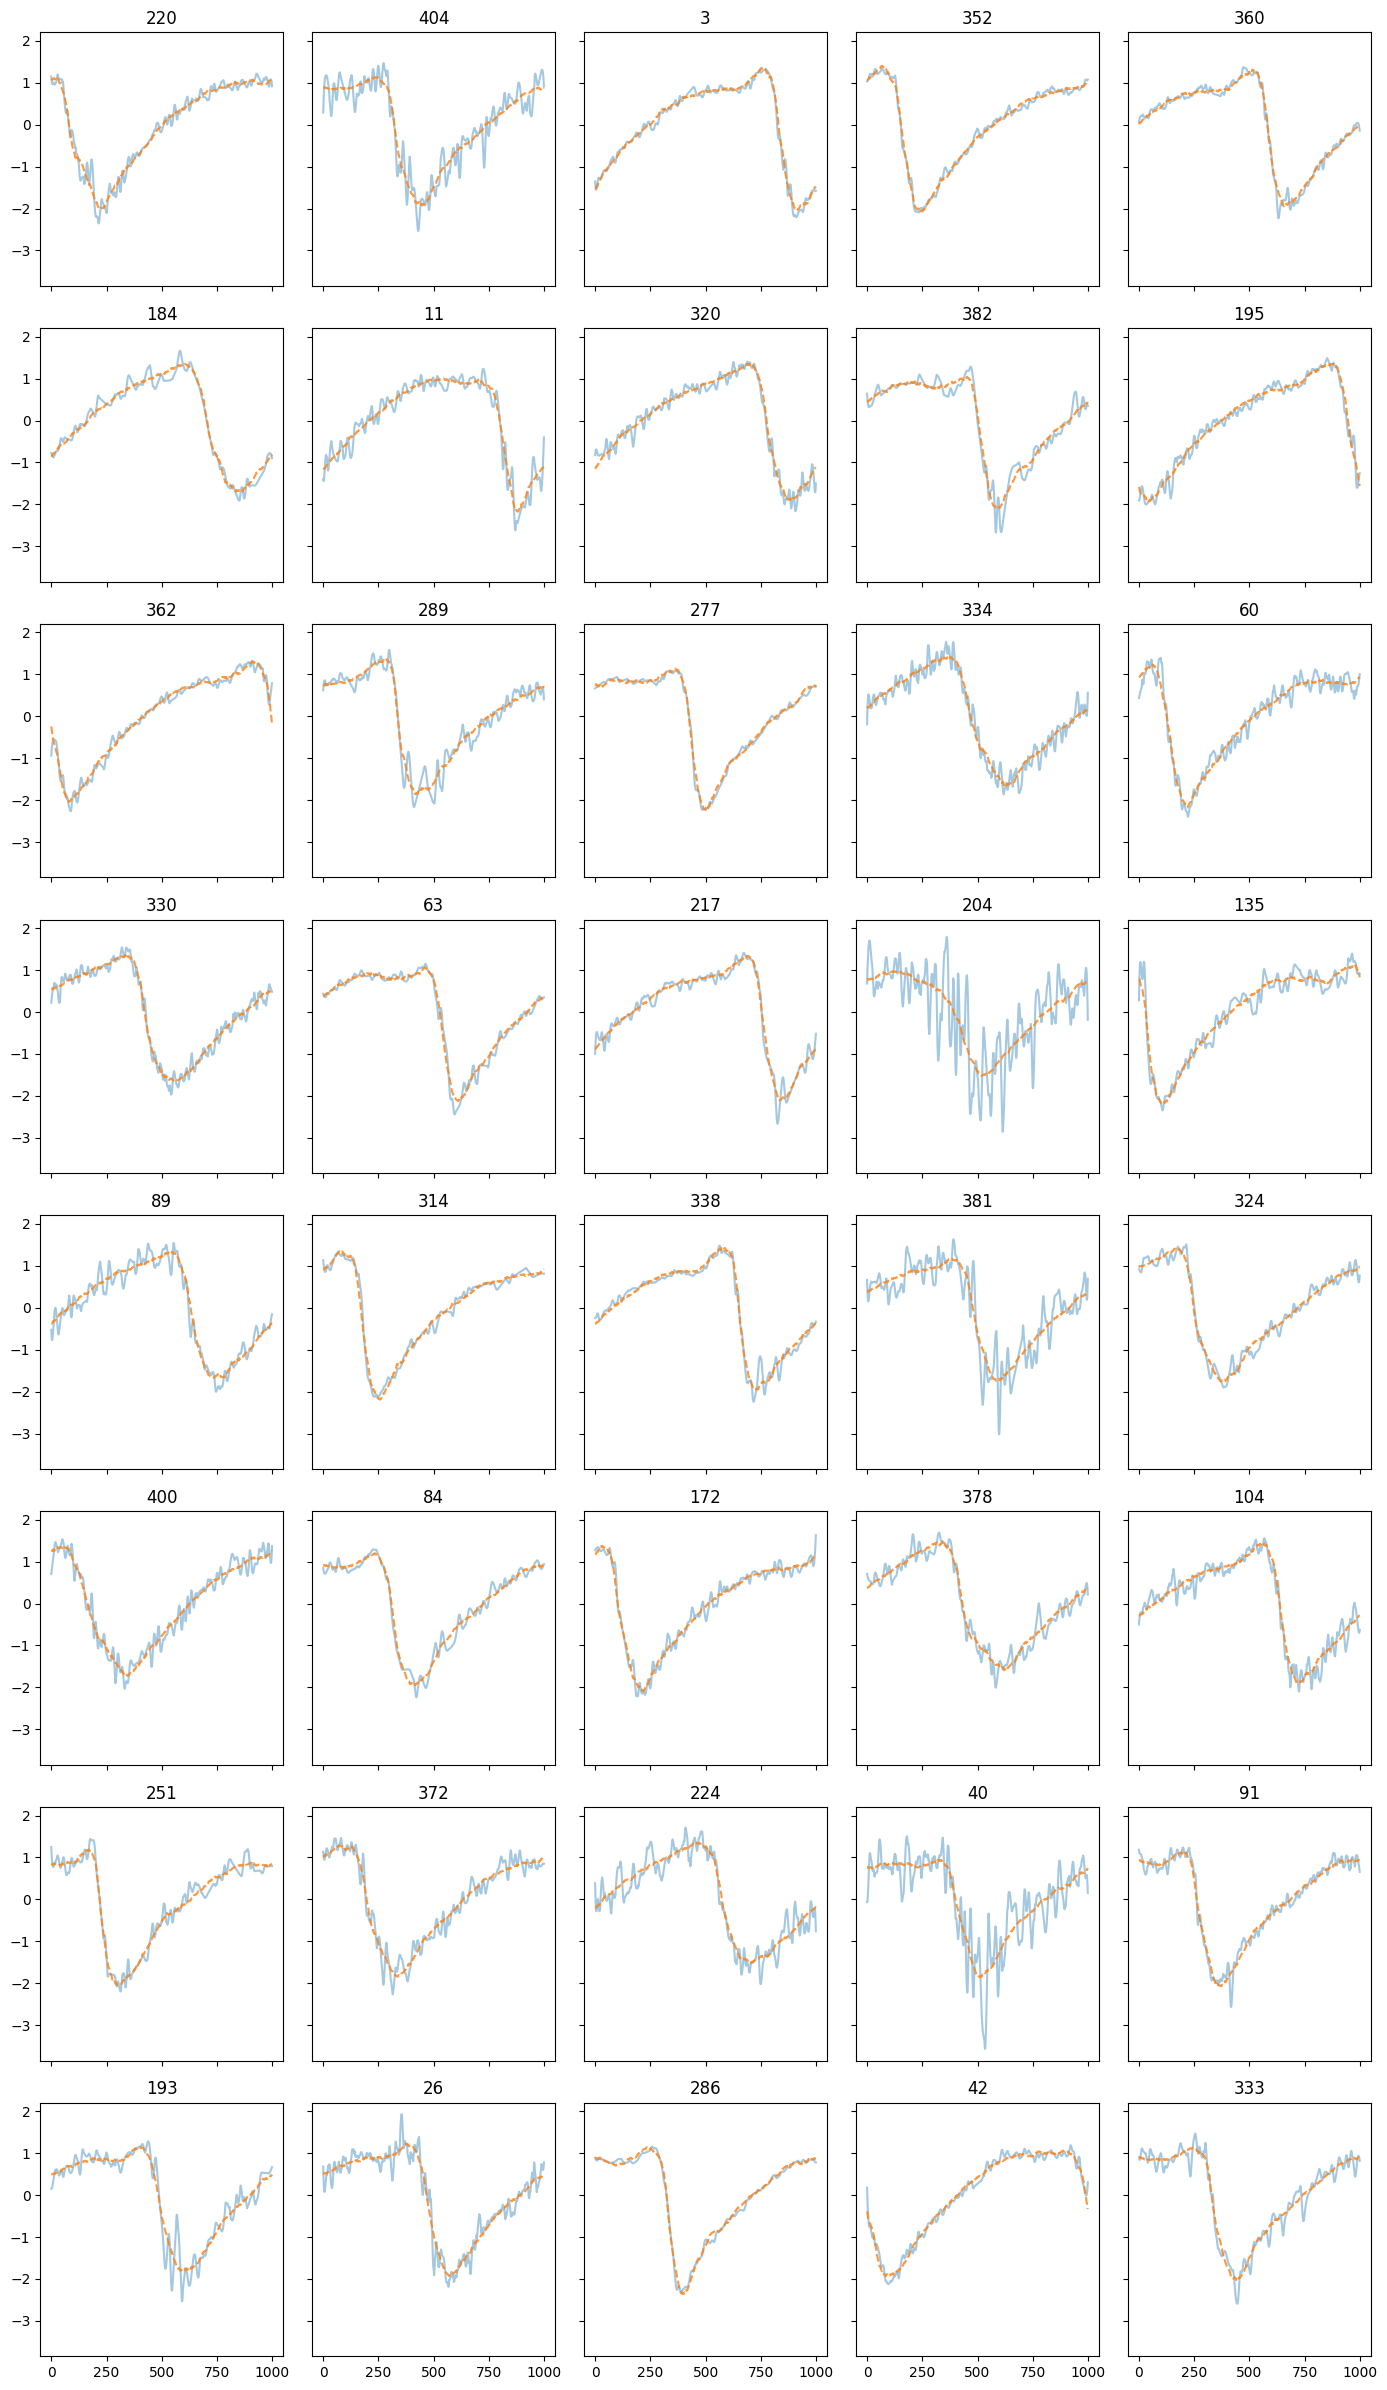

In [29]:
def plot_recon_grid(X, recon, n=40, ncols=5):
    idxs = np.random.choice(len(X), size=n, replace=False)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3*nrows), sharex=True, sharey=True)
    axes = axes.flatten()

    for k, idx in enumerate(idxs):
        ax = axes[k]
        ax.plot(X[idx], alpha=0.4)
        ax.plot(recon[idx], '--', alpha=0.8)
        ax.set_title(f"{idx}")
    
    plt.tight_layout()
    plt.show()

model.eval()
with torch.no_grad():
    x = torch.from_numpy(train_templates).unsqueeze(1).to(device)
    recon, _ = model(x)
recon_np = recon.cpu().numpy()[:,0,:]

plot_recon_grid(train_templates, recon_np, n=40)

### chi2 of fits for CAE and performance comparison with template stars (approximating the AE-smoothed templates as a discrete bank)
Here I am performing a sanity check on the AE-smoothed templates as a 'discrete library' with the 400 templates trained

In [30]:
import numpy as np

def compute_chi2(original, recon, sigma=None):
    if sigma is None:
        sigma = np.std(original - np.median(original))

    chi2 = np.sum(((original - recon) / sigma)**2)
    red_chi2 = chi2 / len(original)
    return chi2, red_chi2

chi2_list = []
for i in range(len(train_templates)):
    orig = train_templates[i]
    rec  = recon_np[i]
    chi2, red_chi2 = compute_chi2(orig, rec)
    chi2_list.append((i, chi2, red_chi2))
chi2_sorted = sorted(chi2_list, key=lambda x: x[2])

In [31]:
ae_templates = {i: recon_np[i] for i in range(len(recon_np))}

In [32]:
def evaluate_template_fits(lc_df, star_ids, templates):
    rows = []
    for sid in star_ids:
        g = lc_df[lc_df["star_id"] == sid]
        if len(g) == 0:
            continue

        t = g["time"].values
        m = g["mag"].values
        err = g["mag_err"].values
        P = g["period"].iloc[0]

        best_tid, fit_result = fit_all_templates_to_star(t, m, err, P, templates)
        if fit_result is None:
            continue

        model = fit_result["model_curve"]
        resid = m - model
        chi2  = np.sum((resid / err)**2)
        ndof = len(m) - 4
        chi2_red = chi2 / ndof if ndof > 0 else np.nan

        rms = np.sqrt(np.mean(resid**2))

        rows.append({
            "star_id": sid,
            "best_tid": best_tid,
            "n_points": len(m),
            "chi2": chi2,
            "ndof": ndof,
            "chi2_red": chi2_red,
            "rms": rms})

    return pd.DataFrame(rows)

In [33]:
good_ids = lc_df_good["star_id"].unique()

fit_stats_ae = evaluate_template_fits(lc_df_good, good_ids, ae_templates)
fit_stats_ae.head()

,star_id,best_tid,n_points,chi2,ndof,chi2_red,rms
0,138,311,181,562.437499,177,3.177613,0.056866
1,218,105,117,3407.466343,113,30.154569,0.178042
2,229,247,164,1779.013328,160,11.118833,0.121088
3,260,253,190,373.164533,186,2.006261,0.050208
4,372,204,144,1864.200583,140,13.315718,0.114236


In [ ]:
fit_stats_discrete = evaluate_template_fits(lc_df_good, good_ids, good_templates)
fit_stats_discrete.head()

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(fit_stats_ae["chi2_red"], bins=50, alpha=0.5, label="AE Templates")
plt.hist(fit_stats_discrete["chi2_red"], bins=50, alpha=0.5, label="Discrete Templates")
plt.xlabel("Reduced χ²")
plt.ylabel("Number of stars")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Plotting AE on sparse stars along with shifts + offsets

In [ ]:
def phase_fold(t, P):
    return ((t - t.min()) / P) % 1.0

def align_template_minimum(y):
    i_min = np.argmin(y)
    return np.roll(y, -i_min)

def spline_from_template(template):
    y = np.asarray(template, float).squeeze().copy()
    y = align_template_minimum(y)
    y[0] = y[-1] = 0.5*(y[0] + y[-1]) #matching boundaries

    L_local = len(y)
    x = np.linspace(0, 1, L_local, endpoint=False)
    return CubicSpline(x, y, bc_type="periodic")

def ae_decode_1d(model, z_vec):
    z_t = torch.tensor(z_vec, dtype=torch.float32, device=device).unsqueeze(0)  # (1,latent)
    model.eval()
    with torch.no_grad():
        y = model.decode(z_t).cpu().numpy()[0,0,:]
    return y

def fit_m0_A(m, err, shape):
    w = 1.0 / (err**2)
    X = np.column_stack([np.ones_like(shape), shape])
    XtW = X.T * w
    beta = np.linalg.solve(XtW @ X, XtW @ m)
    m0, A = beta
    return m0, A


#### Optimize z (latent vector), phi0 (phase shift), s (stretch), and solve m0 and A analytically

In [ ]:
def fit_continuous_ae_for_star(t, m, err, P, model, latent_dim, allow_stretch=True):
    phase = phase_fold(t, P)

    x0 = np.concatenate([np.zeros(latent_dim), [0.0, 1.0]])

    bounds = [(-3.0, 3.0)] * latent_dim 
    bounds.append((-0.5, 0.5))   
    bounds.append((0.90, 1.10) if allow_stretch else (0.995, 1.005))

    def chi2(x):
        z = x[:latent_dim]
        phi0 = x[-2]
        s = x[-1]

        tmpl = ae_decode_1d(model, z)
        spline = spline_from_template(tmpl)

        ph = (phase * s - phi0) % 1.0
        shape = spline(ph)

        m0, A = fit_m0_A(m, err, shape)
        model_curve = m0 + A * shape

        return np.sum(((m - model_curve) / err)**2)

    sol = minimize(chi2, x0, bounds=bounds, method="L-BFGS-B")
    if not sol.success:
        return None

    x_best = sol.x
    z_best = x_best[:latent_dim]
    phi0_best = x_best[-2]
    s_best = x_best[-1]

    tmpl_best = ae_decode_1d(model, z_best)
    spline_best = spline_from_template(tmpl_best)

    ph = ((phase - phi0_best) * s_best) % 1.0
    shape = spline_best(ph)
    m0_best, A_best = fit_m0_A(m, err, shape)
    model_curve = m0_best + A_best * shape

    dense_phase = np.linspace(0.0, 1.0, 2000, endpoint=False)
    dense_shape = spline_best(((dense_phase - phi0_best) * s_best) % 1.0)
    dense_model = m0_best + A_best * dense_shape

    chi2_best = np.sum(((m - model_curve) / err)**2)

    return {
        "z": z_best,
        "m0": m0_best,
        "A": A_best,
        "phi0": phi0_best,
        "s": s_best,
        "chi2": chi2_best,
        "phase": phase,
        "model_curve": model_curve,
        "dense_phase": dense_phase,
        "dense_model": dense_model}

In [ ]:
def plot_single_ae_fit(sid, df, model, latent_dim, title_prefix="AE Fit"):
    g = df[df["star_id"] == sid]
    t   = g["time"].values
    m   = g["mag"].values
    err = g["mag_err"].values
    P   = g["period"].iloc[0]

    fit = fit_continuous_ae_for_star(t, m, err, P, model, latent_dim)

    if fit is None:
        print(f"AE fit failed for star {sid}")
        return

    phase = fit["phase"]
    srt   = np.argsort(phase)

    plt.figure(figsize=(7,5))
    plt.errorbar(phase[srt], m[srt], yerr=err[srt],
                 fmt='o', markersize=3, alpha=0.7, label="Data")
    plt.plot(phase[srt], fit["model_curve"][srt],
             'r--', lw=2, label="AE Fit")
    
    plt.gca().invert_yaxis()
    plt.xlabel("Phase")
    plt.ylabel("Magnitude")
    plt.title(f"{title_prefix} | {sid} | χ² = {fit['chi2']:.1f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return fit

In [ ]:
import numpy as np

df_test = lc_df_bad
sample_ids = np.random.choice(df_test["star_id"].unique(), size=20, replace=False)

In [ ]:
for sid in sample_ids:
    print(f"BEST FIT STAR {sid}")
    plot_single_ae_fit(sid, lc_df_bad, model, LATENT_DIM, title_prefix="AE 20")